In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/customer_booking.csv', encoding='latin1')
df

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2,Internet,RoundTrip,27,6,9,Sat,PERPNH,Australia,1,0,1,5.62,0
49996,1,Internet,RoundTrip,111,6,4,Sun,PERPNH,Australia,0,0,0,5.62,0
49997,1,Internet,RoundTrip,24,6,22,Sat,PERPNH,Australia,0,0,1,5.62,0
49998,1,Internet,RoundTrip,15,6,11,Mon,PERPNH,Australia,1,0,1,5.62,0


In [ ]:
df.shape

(50000, 14)

In [ ]:
df.columns

Index(['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead',
       'length_of_stay', 'flight_hour', 'flight_day', 'route',
       'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals', 'flight_duration', 'booking_complete'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [ ]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [ ]:
df.isna().sum()

,0
num_passengers,0
sales_channel,0
trip_type,0
purchase_lead,0
length_of_stay,0
flight_hour,0
flight_day,0
route,0
booking_origin,0
wants_extra_baggage,0


In [ ]:
df.duplicated().sum()

np.int64(719)

In [ ]:
df[df.duplicated()]

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
196,5,Internet,RoundTrip,206,17,13,Sun,AKLKUL,Malaysia,1,0,0,8.83,0
316,5,Internet,RoundTrip,206,17,13,Sun,AKLKUL,Malaysia,1,0,0,8.83,0
384,5,Internet,RoundTrip,206,17,13,Sun,AKLKUL,Malaysia,1,0,0,8.83,0
456,1,Internet,RoundTrip,30,85,15,Fri,AKLKUL,Malaysia,1,0,0,8.83,1
513,3,Internet,RoundTrip,109,20,4,Tue,AKLKUL,Singapore,1,0,1,8.83,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49852,2,Internet,RoundTrip,204,6,14,Tue,PENTPE,Malaysia,1,0,0,4.67,0
49902,1,Mobile,RoundTrip,106,6,11,Fri,PENTPE,Taiwan,1,0,0,4.67,0
49934,1,Internet,RoundTrip,2,6,3,Thu,PENTPE,Malaysia,0,0,1,4.67,0
49944,1,Internet,RoundTrip,2,6,3,Thu,PENTPE,Malaysia,0,0,1,4.67,0


In [ ]:
df = df.drop_duplicates(keep='first').copy()

In [ ]:
df.duplicated().sum()

np.int64(0)

# Distribution (Categorical vs Numerical)


In [ ]:
nos_col = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_col = df.select_dtypes(include=['bool','object']).columns.tolist()

In [ ]:
cat_col

['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin']

In [ ]:
nos_col

['num_passengers',
 'purchase_lead',
 'length_of_stay',
 'flight_hour',
 'wants_extra_baggage',
 'wants_preferred_seat',
 'wants_in_flight_meals',
 'flight_duration',
 'booking_complete']

In [ ]:
for col in cat_col:
    print(col, df[col].unique())

sales_channel ['Internet' 'Mobile']
trip_type ['RoundTrip' 'CircleTrip' 'OneWay']
flight_day ['Sat' 'Wed' 'Thu' 'Mon' 'Sun' 'Tue' 'Fri']
route ['AKLDEL' 'AKLHGH' 'AKLHND' 'AKLICN' 'AKLKIX' 'AKLKTM' 'AKLKUL' 'AKLMRU'
 'AKLPEK' 'AKLPVG' 'AKLTPE' 'AORICN' 'AORKIX' 'AORKTM' 'AORMEL' 'BBIMEL'
 'BBIOOL' 'BBIPER' 'BBISYD' 'BDOCTS' 'BDOCTU' 'BDOHGH' 'BDOICN' 'BDOIKA'
 'BDOKIX' 'BDOMEL' 'BDOOOL' 'BDOPEK' 'BDOPER' 'BDOPUS' 'BDOPVG' 'BDOSYD'
 'BDOTPE' 'BDOXIY' 'BKICKG' 'BKICTS' 'BKICTU' 'BKIHND' 'BKIICN' 'BKIKIX'
 'BKIKTM' 'BKIMEL' 'BKIMRU' 'BKIOOL' 'BKIPEK' 'BKIPER' 'BKIPUS' 'BKIPVG'
 'BKISYD' 'BKIXIY' 'BLRICN' 'BLRMEL' 'BLRPER' 'BLRSYD' 'BOMMEL' 'BOMOOL'
 'BOMPER' 'BOMSYD' 'BTJJED' 'BTUICN' 'BTUPER' 'BTUSYD' 'BTUWUH' 'BWNCKG'
 'BWNDEL' 'BWNHGH' 'BWNIKA' 'BWNKTM' 'BWNMEL' 'BWNOOL' 'BWNPER' 'BWNSYD'
 'BWNTPE' 'CANDEL' 'CANIKA' 'CANMEL' 'CANMRU' 'CANOOL' 'CANPER' 'CANSYD'
 'CCUMEL' 'CCUMRU' 'CCUOOL' 'CCUPER' 'CCUSYD' 'CCUTPE' 'CEBMEL' 'CEBOOL'
 'CEBPER' 'CEBSYD' 'CGKCKG' 'CGKCTS' 'CGKCTU' 'CGKDEL'

# Numerical Univariate analysis

In [ ]:
def num_univariate_analysis(df, col):

    plt.figure(figsize=(15,10))

    # 1. Histogram
    plt.subplot(2,2,1)
    df[col].hist(bins=30)
    plt.title(f'Histogram of {col}')

    # 2. Boxplot
    plt.subplot(2,2,2)
    df.boxplot(column=col)
    plt.title(f'Boxplot of {col}')


    # 3. KDE Plot
    plt.subplot(2,2,3)
    df[col].plot(kind='kde')
    plt.title(f'KDE Plot of {col}')

    # 4. Violin Plot
    plt.subplot(2,2,4)
    sns.violinplot(x=df[col])
    plt.title(f'Violin Plot of {col}')

    plt.tight_layout()
    plt.show()

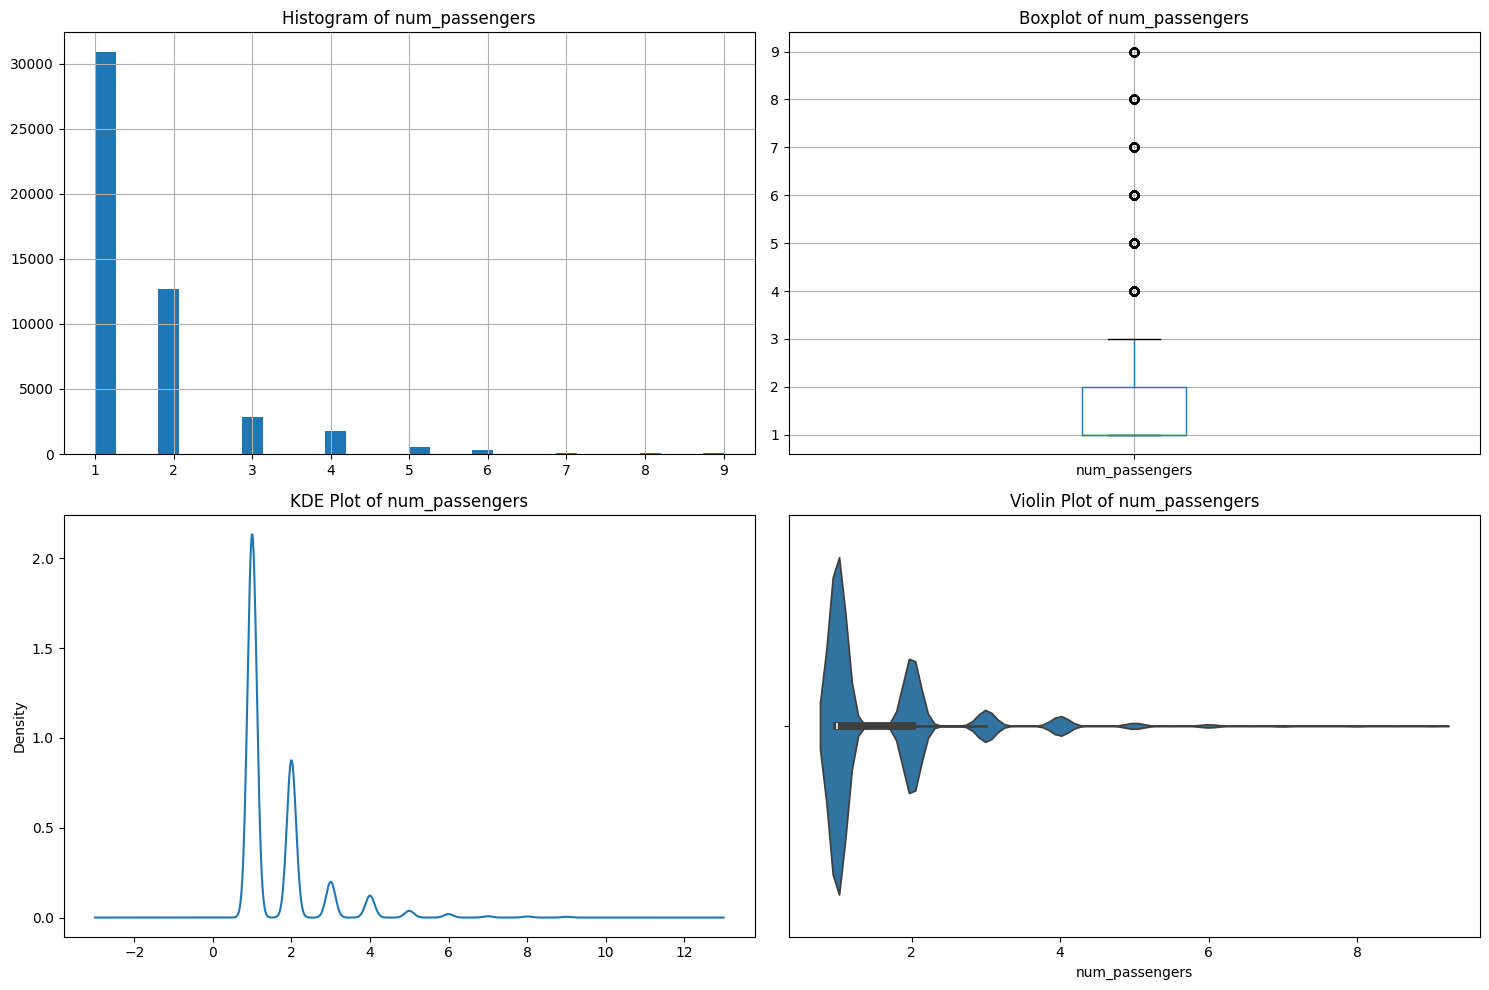

In [ ]:
num_univariate_analysis(df,'num_passengers')

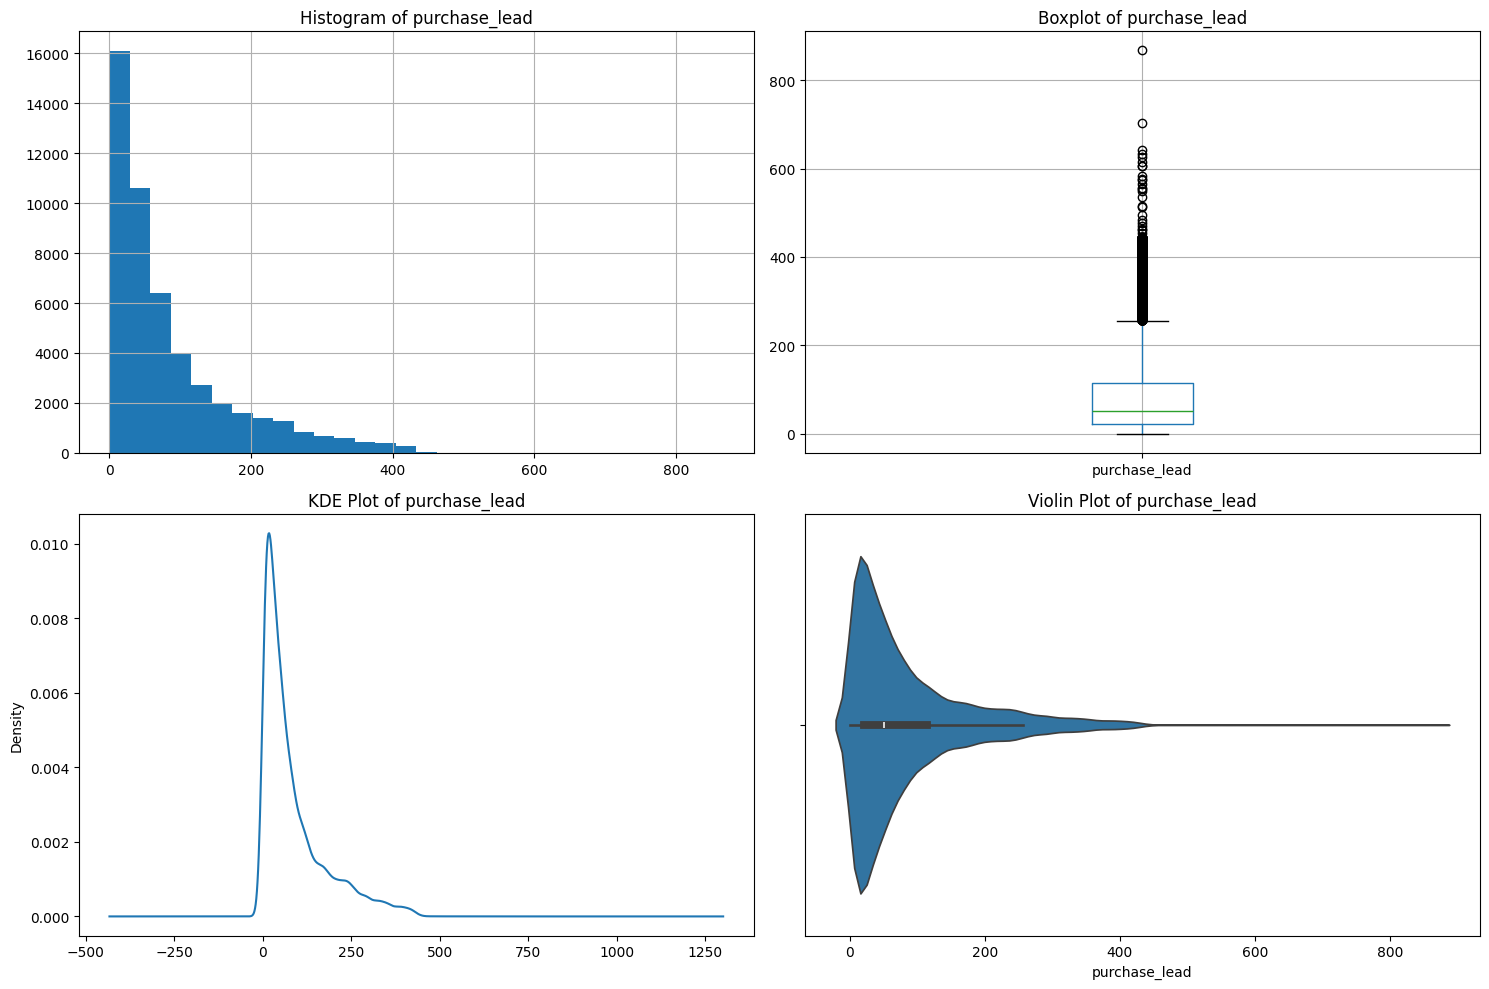

In [ ]:
num_univariate_analysis(df,'purchase_lead')

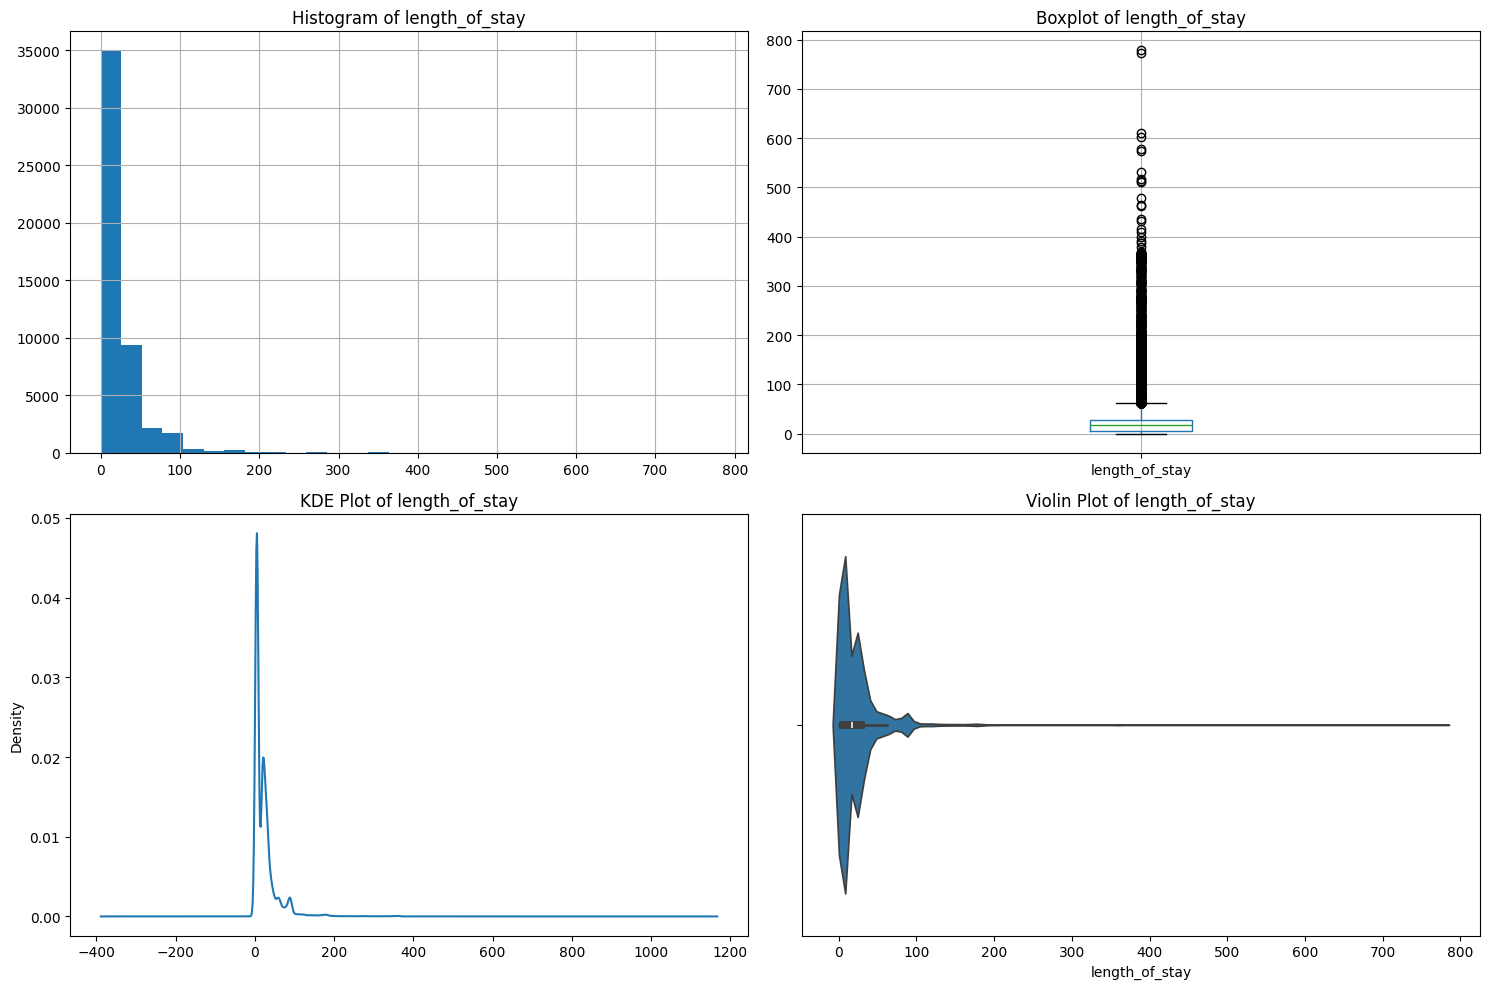

In [ ]:
num_univariate_analysis(df,'length_of_stay')


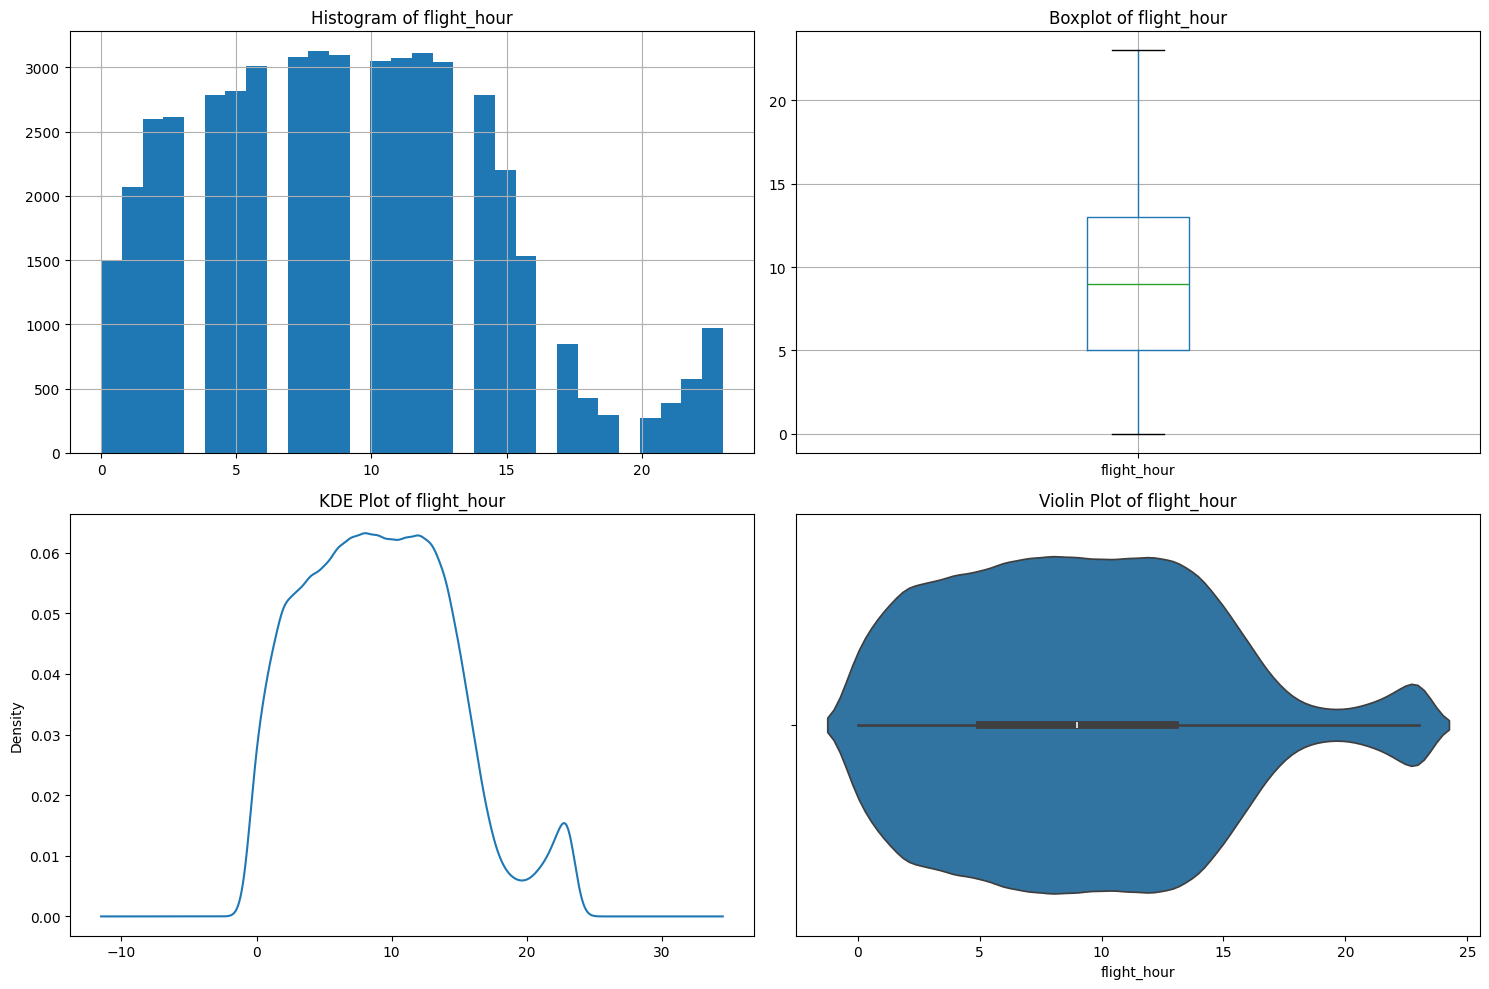

In [ ]:
num_univariate_analysis(df,'flight_hour')

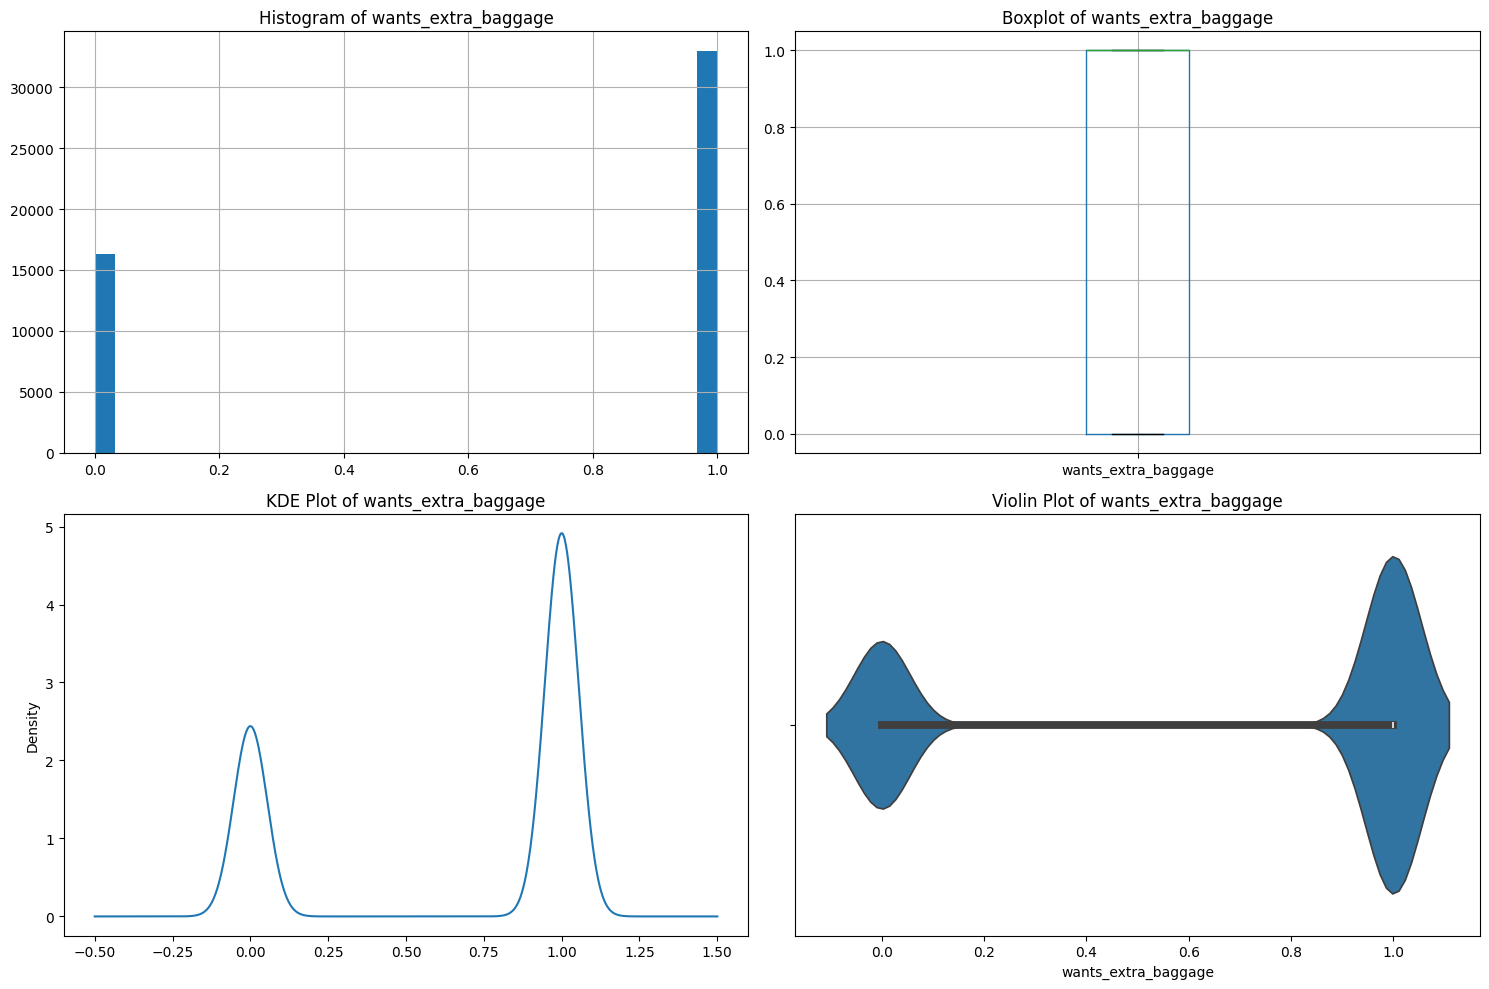

In [ ]:
num_univariate_analysis(df,'wants_extra_baggage')

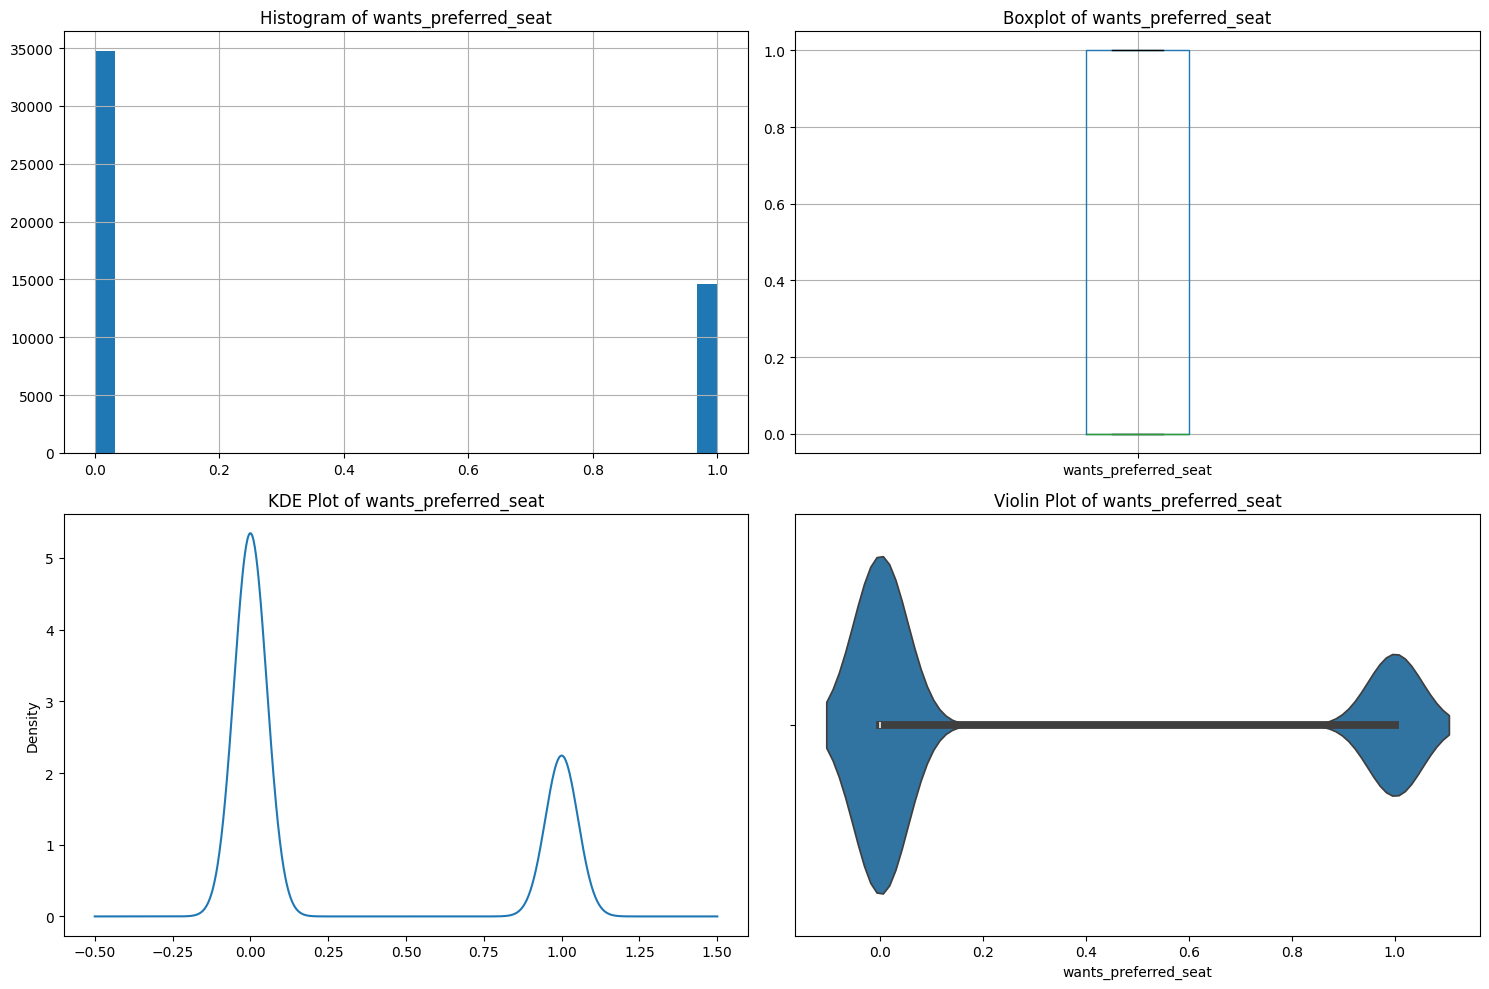

In [ ]:
num_univariate_analysis(df,'wants_preferred_seat')

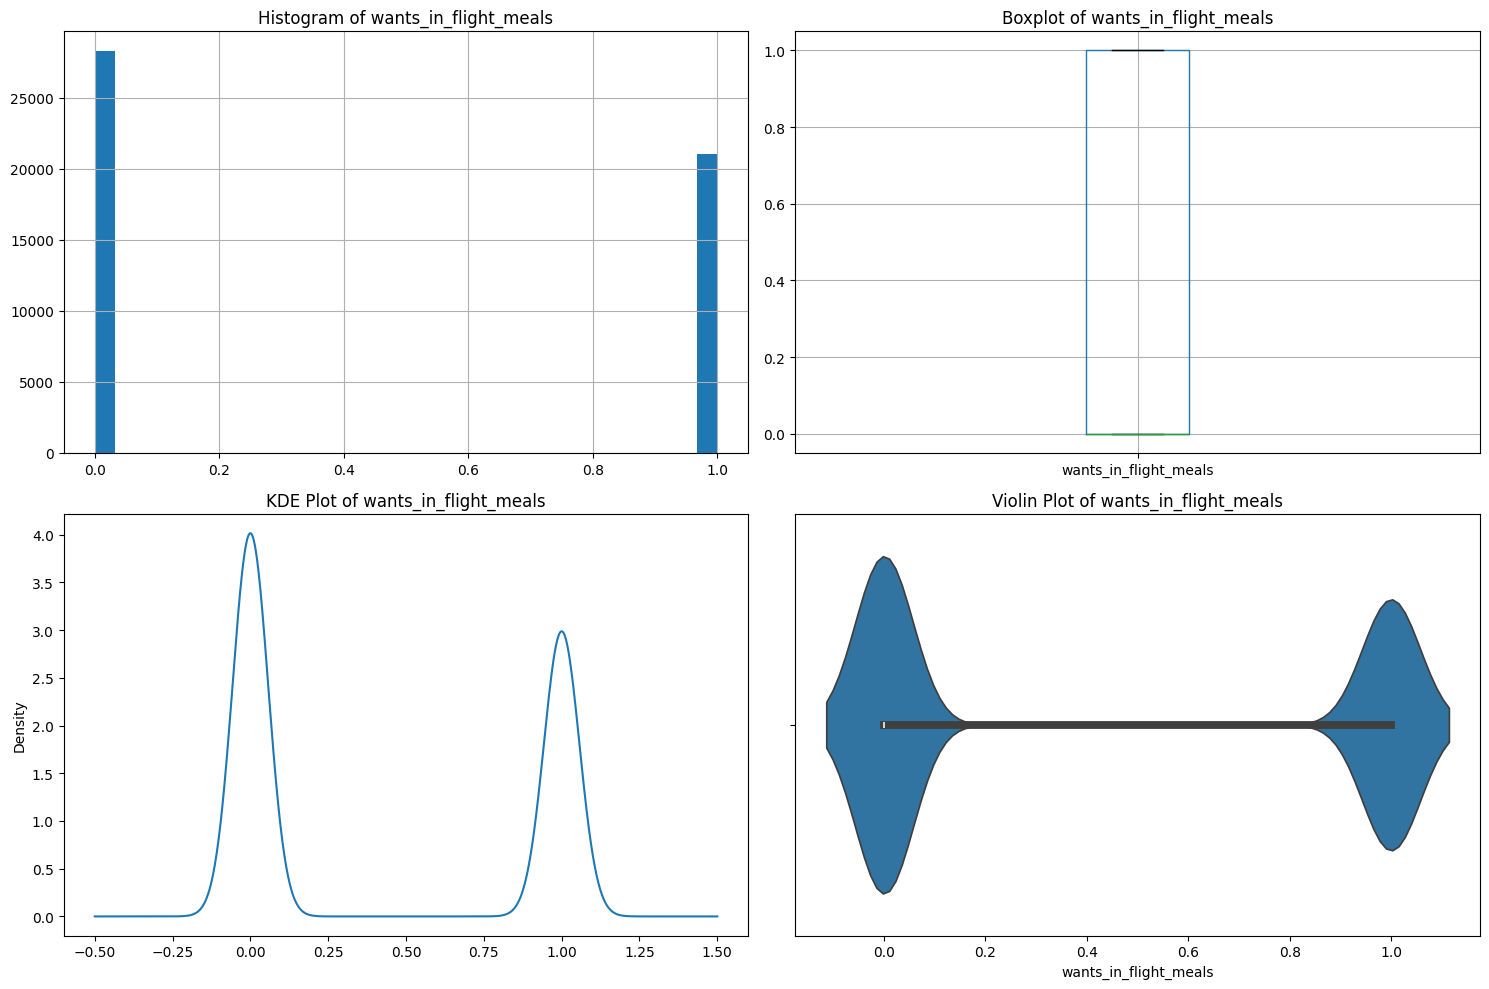

In [ ]:
num_univariate_analysis(df,'wants_in_flight_meals')

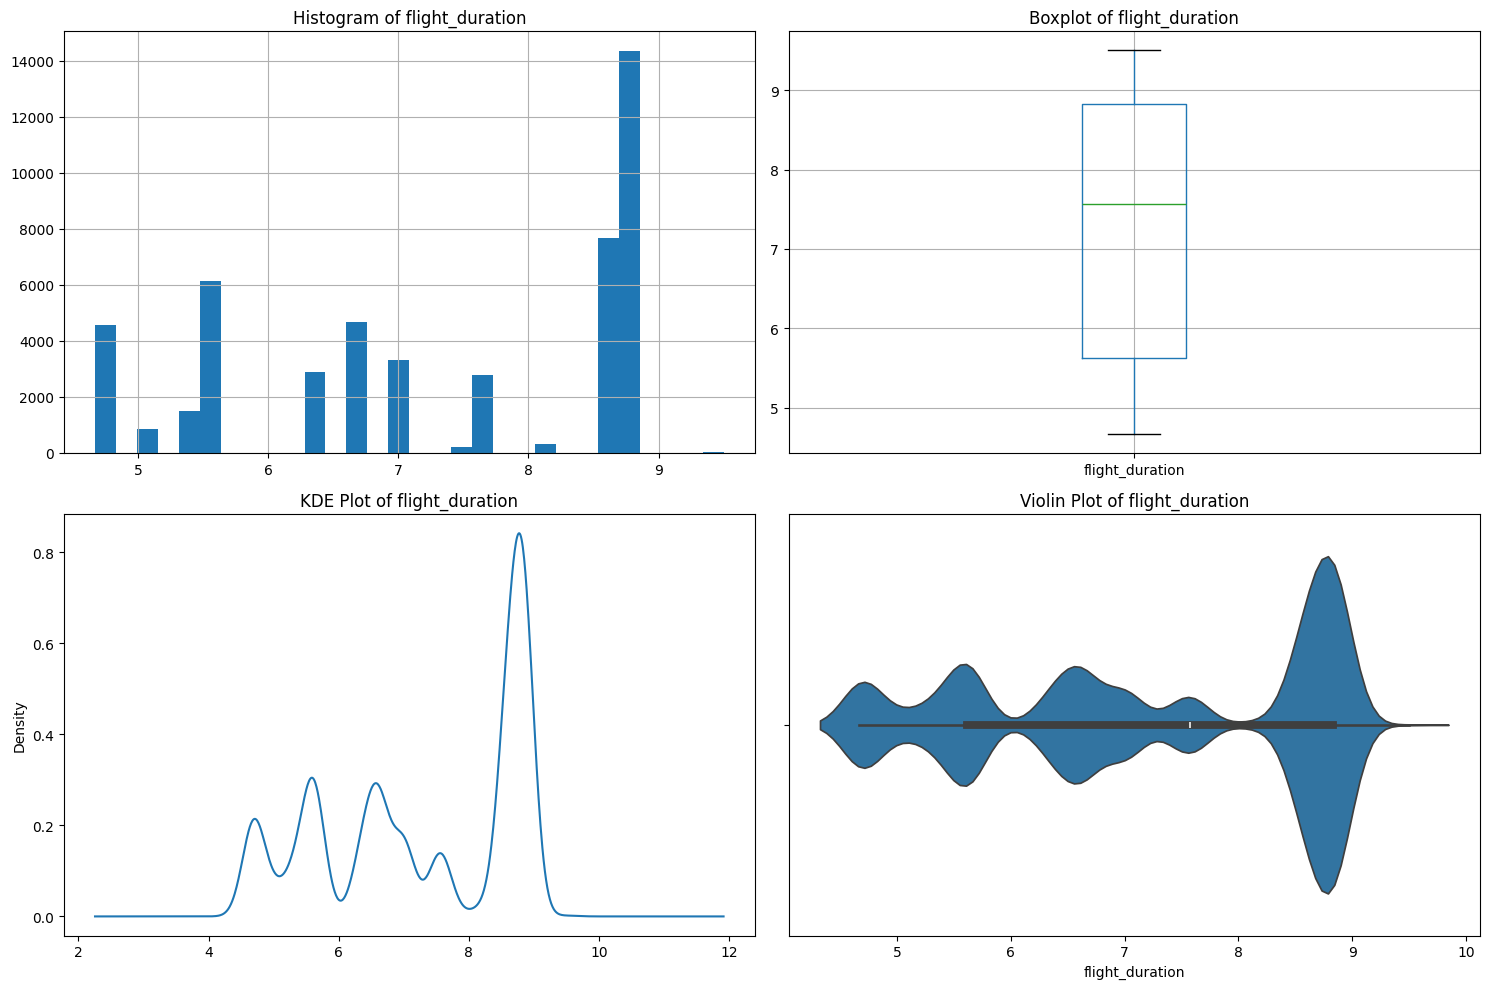

In [ ]:
num_univariate_analysis(df,'flight_duration')

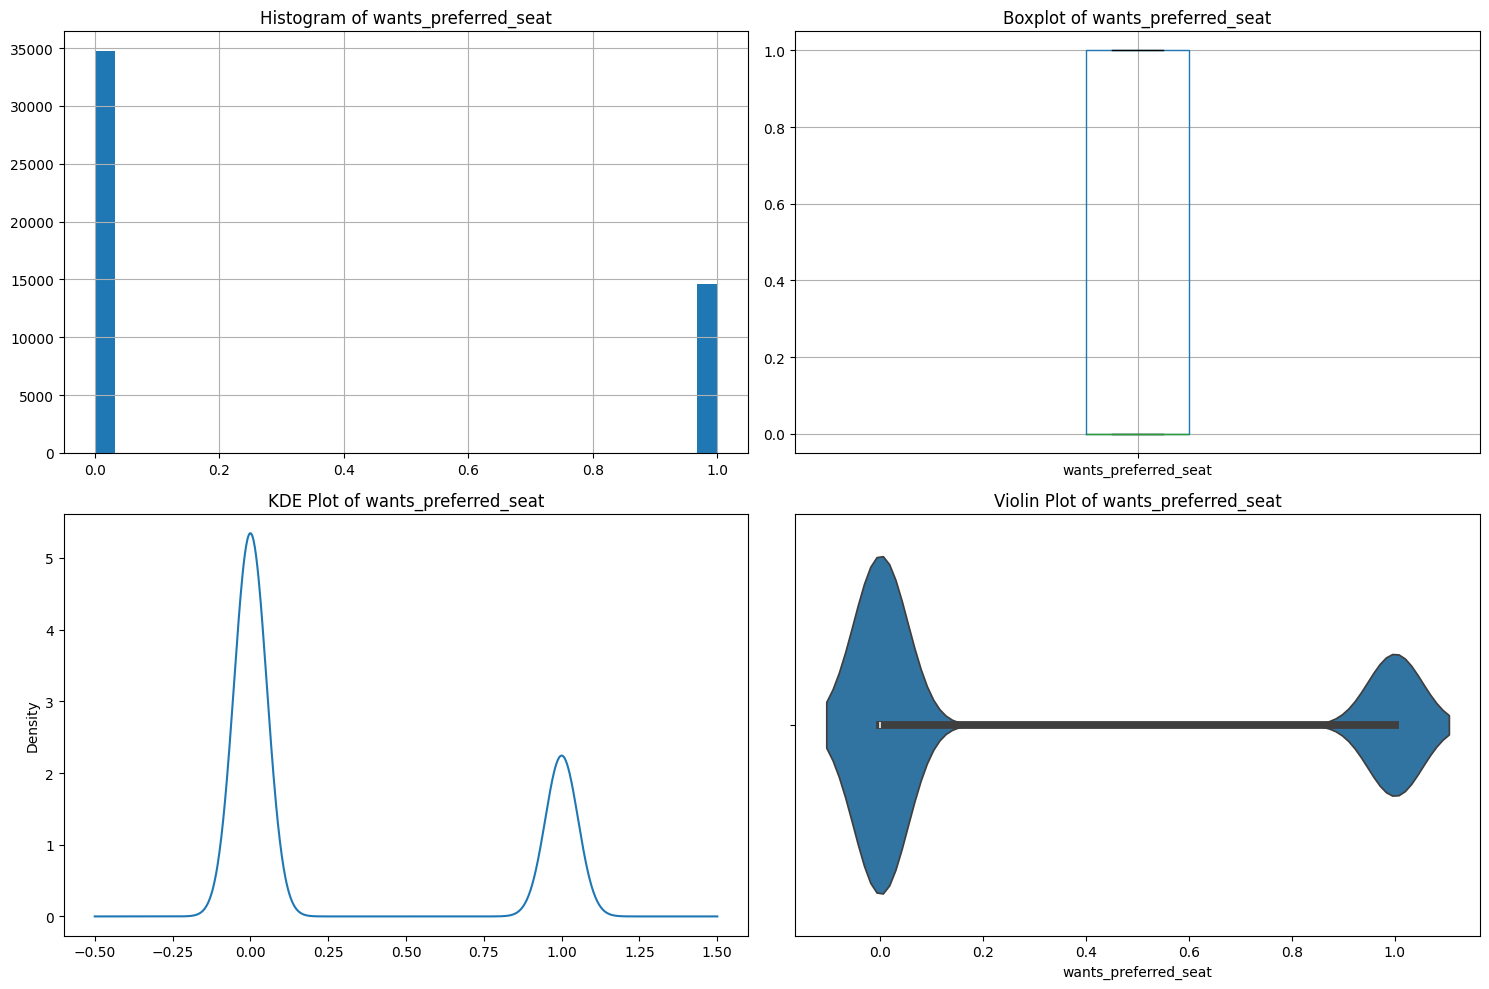

In [ ]:
num_univariate_analysis(df,'wants_preferred_seat',)

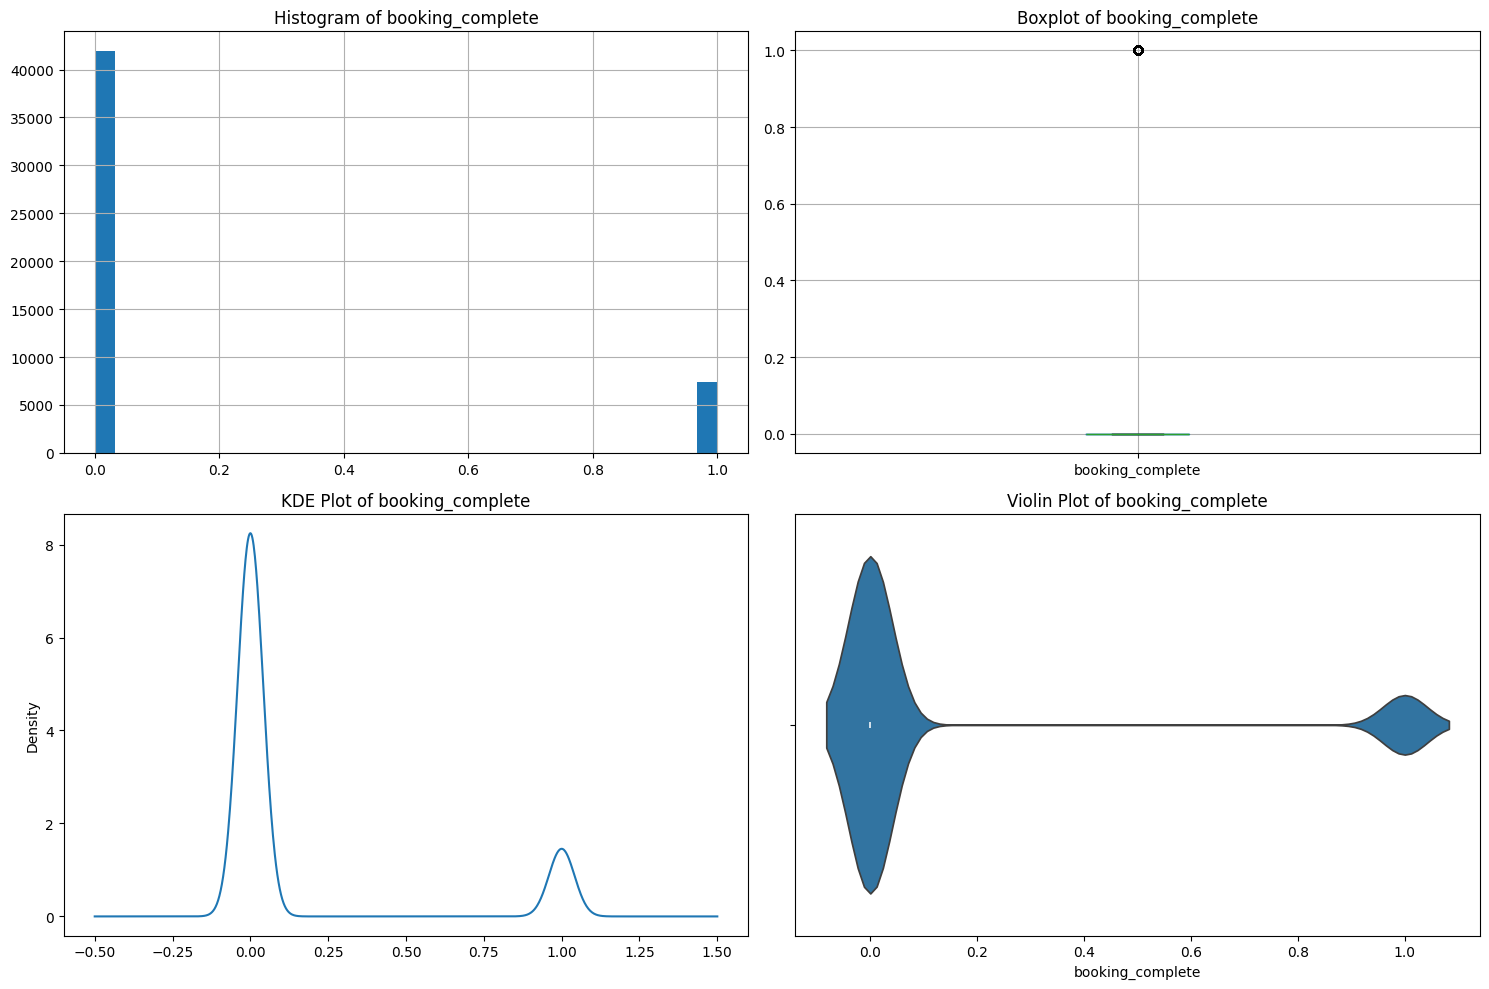

In [ ]:
num_univariate_analysis(df,'booking_complete')

# Categorical Univariate Analysis

In [ ]:
def cat_univariate_analysis(df, col):

    plt.figure(figsize=(10,7))

    # 1. Count Plot
    plt.subplot(2,2,1)
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)


    # 2. Pie Chart
    plt.subplot(2,2,2)
    df[col].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.ylabel('')
    plt.title(f'Pie Chart of {col}')

    # 3. Top Categories (clean view)
    plt.subplot(2,2,3)
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Top Categories of {col}')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [ ]:
cat_col

['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin']

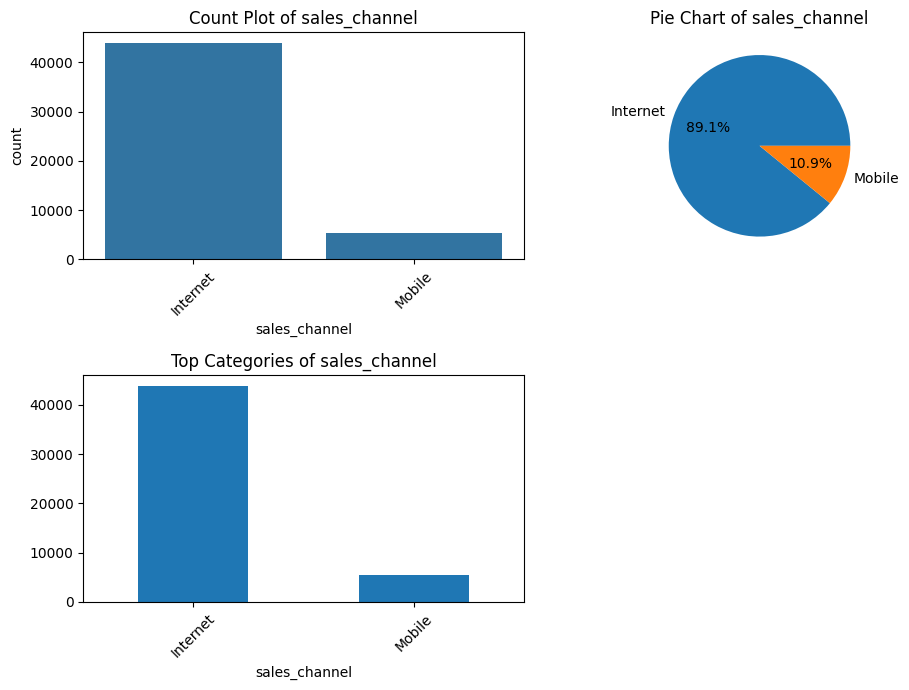

In [ ]:
cat_univariate_analysis(df,'sales_channel')

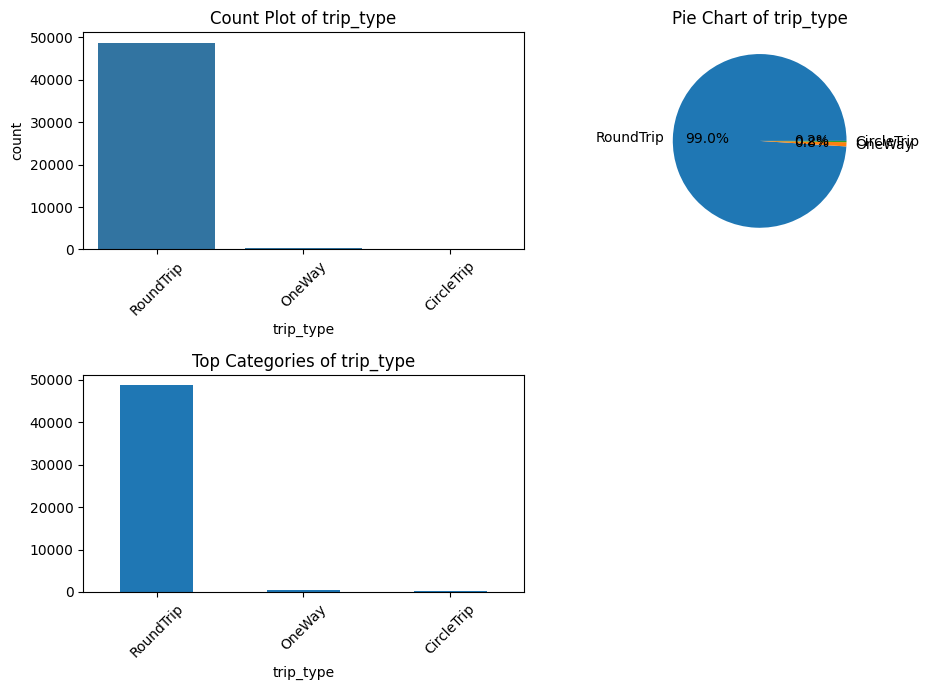

In [ ]:
cat_univariate_analysis(df,'trip_type')

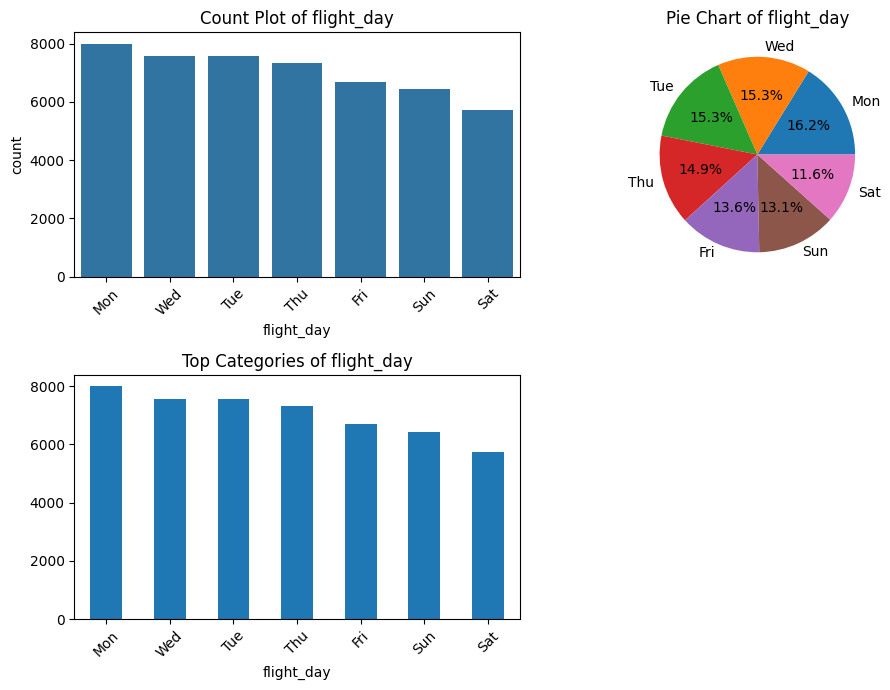

In [ ]:
cat_univariate_analysis(df,'flight_day')

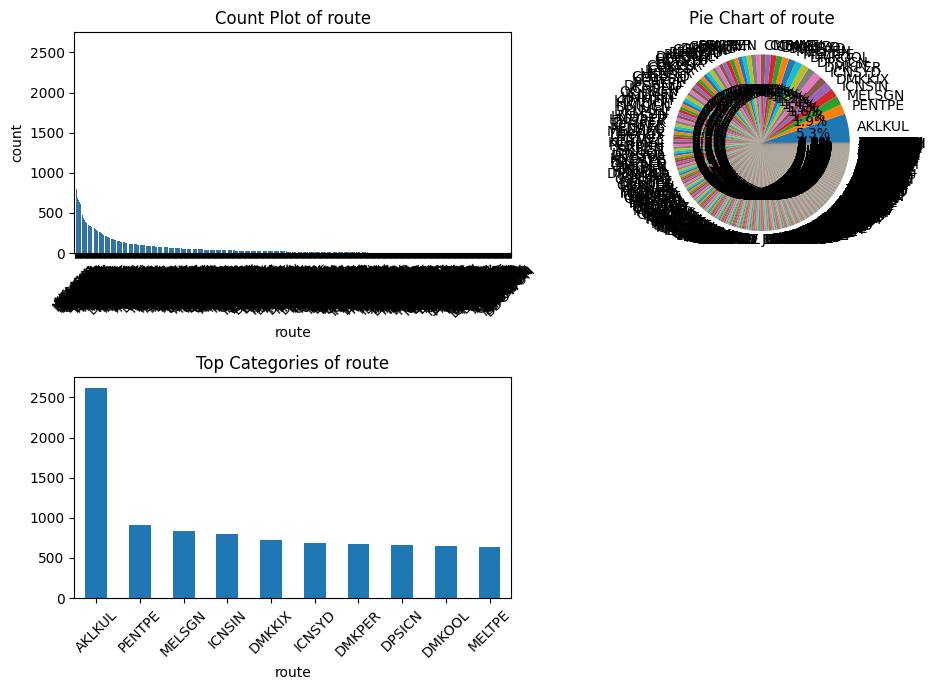

In [ ]:
cat_univariate_analysis(df,'route')

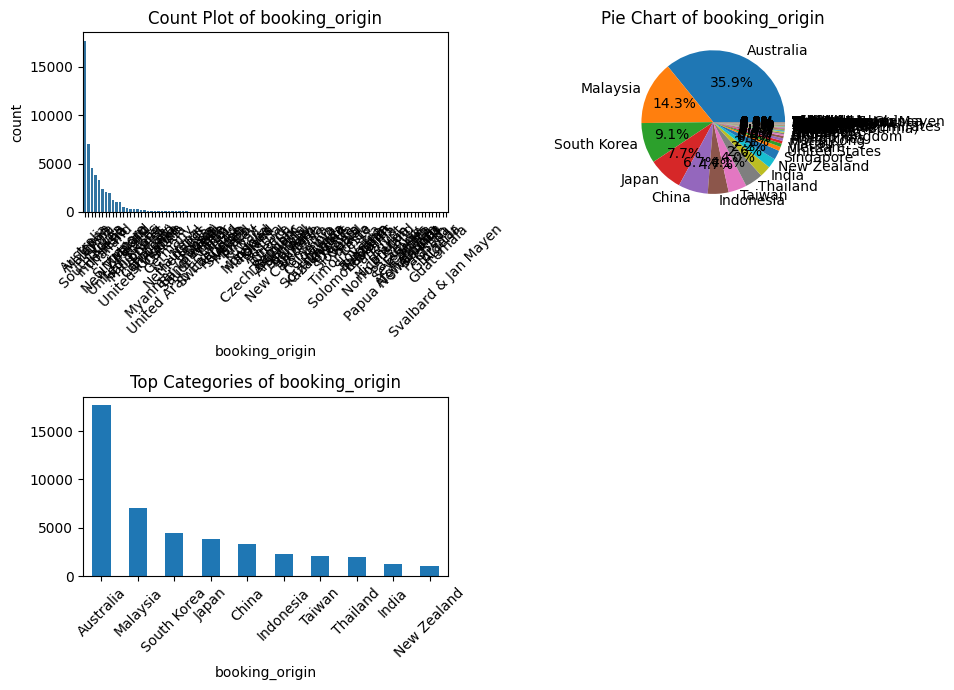

In [ ]:
cat_univariate_analysis(df,'booking_origin')

# Numerical vs Target Bivariate Analysis

In [ ]:
corr = df.corr(numeric_only=True)
print(corr['booking_complete'].sort_values(ascending=False))

booking_complete         1.000000
wants_extra_baggage      0.068452
wants_preferred_seat     0.050189
wants_in_flight_meals    0.026399
num_passengers           0.024092
flight_hour              0.006705
purchase_lead           -0.022132
length_of_stay          -0.042080
flight_duration         -0.106529
Name: booking_complete, dtype: float64


In [ ]:
def num_vs_target_analysis(df, num_col, target_col):

    plt.figure(figsize=(15,10))

    # 1. Box Plot
    plt.subplot(2,2,1)
    sns.boxplot(x=df[target_col], y=df[num_col])
    plt.title(f'{num_col} vs {target_col} (Box Plot)')

    # 2. Violin Plot
    plt.subplot(2,2,2)
    sns.violinplot(x=df[target_col], y=df[num_col])
    plt.title(f'{num_col} vs {target_col} (Violin Plot)')

    # 3. KDE Plot
    plt.subplot(2,2,3)
    for val in df[target_col].unique():
        sns.kdeplot(df[df[target_col]==val][num_col], label=f'{target_col}={val}')
    plt.title(f'{num_col} Distribution by {target_col}')
    plt.legend()

    # 4. Mean Comparison
    plt.subplot(2,2,4)
    df.groupby(target_col)[num_col].mean().plot(kind='bar')
    plt.title(f'Mean {num_col} by {target_col}')

    plt.tight_layout()
    plt.show()

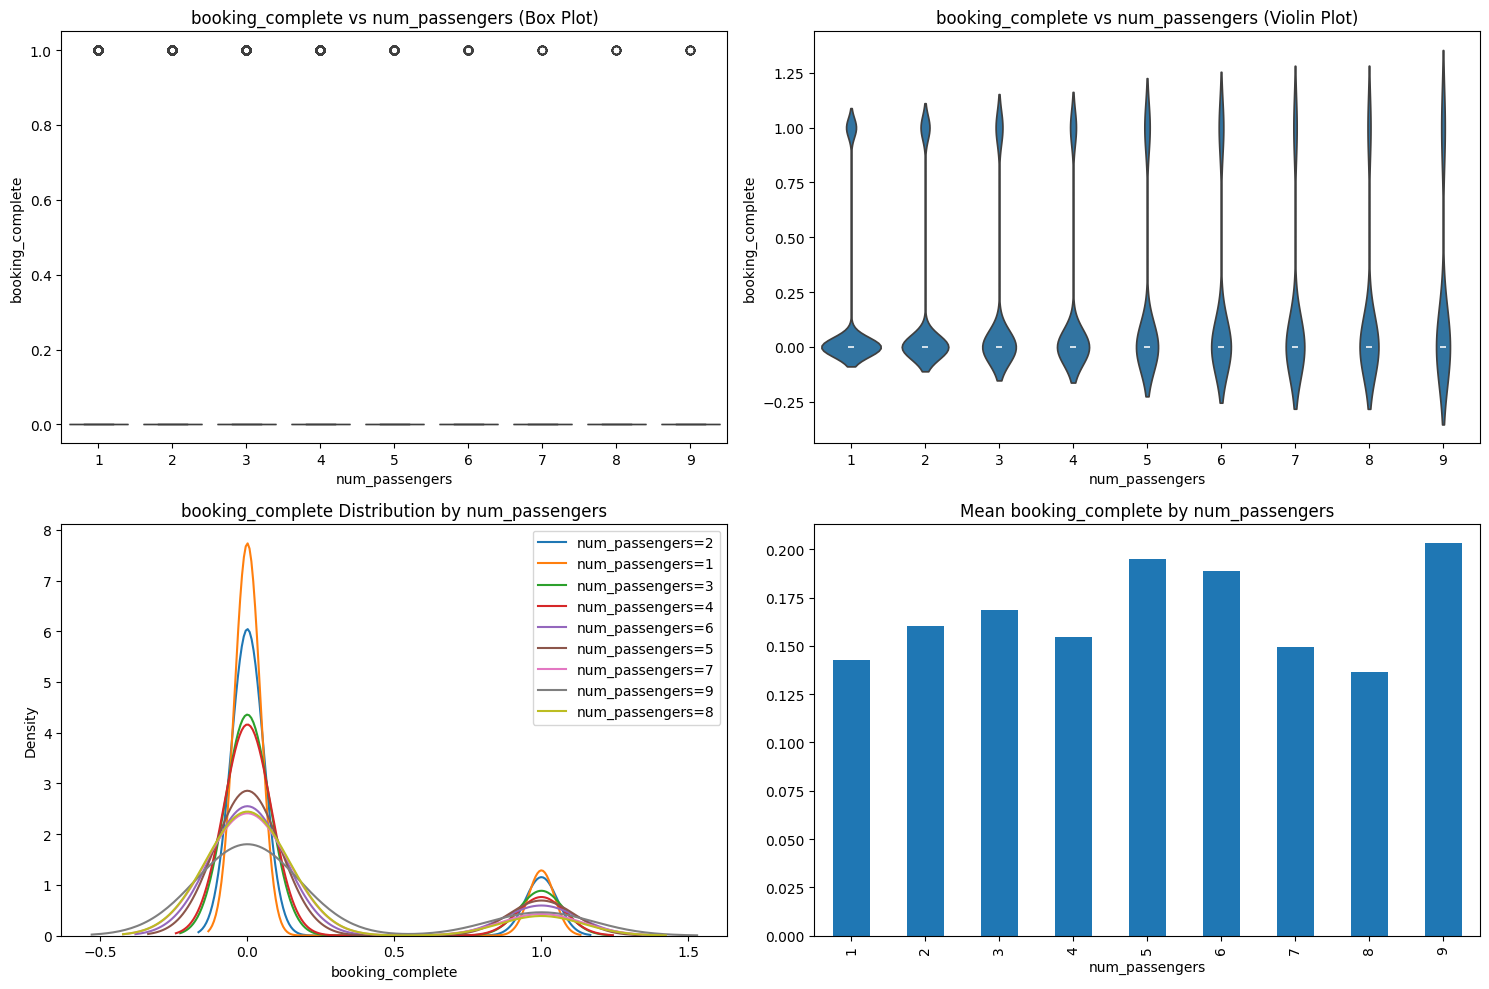

In [ ]:
num_vs_target_analysis(df, 'booking_complete', 'num_passengers')

/tmp/ipykernel_25835/368361378.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df[target_col]==val][num_col], label=f'{target_col}={val}')
/tmp/ipykernel_25835/368361378.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df[target_col]==val][num_col], label=f'{target_col}={val}')
/tmp/ipykernel_25835/368361378.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df[target_col]==val][num_col], label=f'{target_col}={val}')
/tmp/ipykernel_25835/368361378.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df[target_col]==val][num_col], label=f'{target_col}={val}')
/tmp/ipykernel_25835/368361378.py:18: UserWarning: Dataset has 0 variance; s

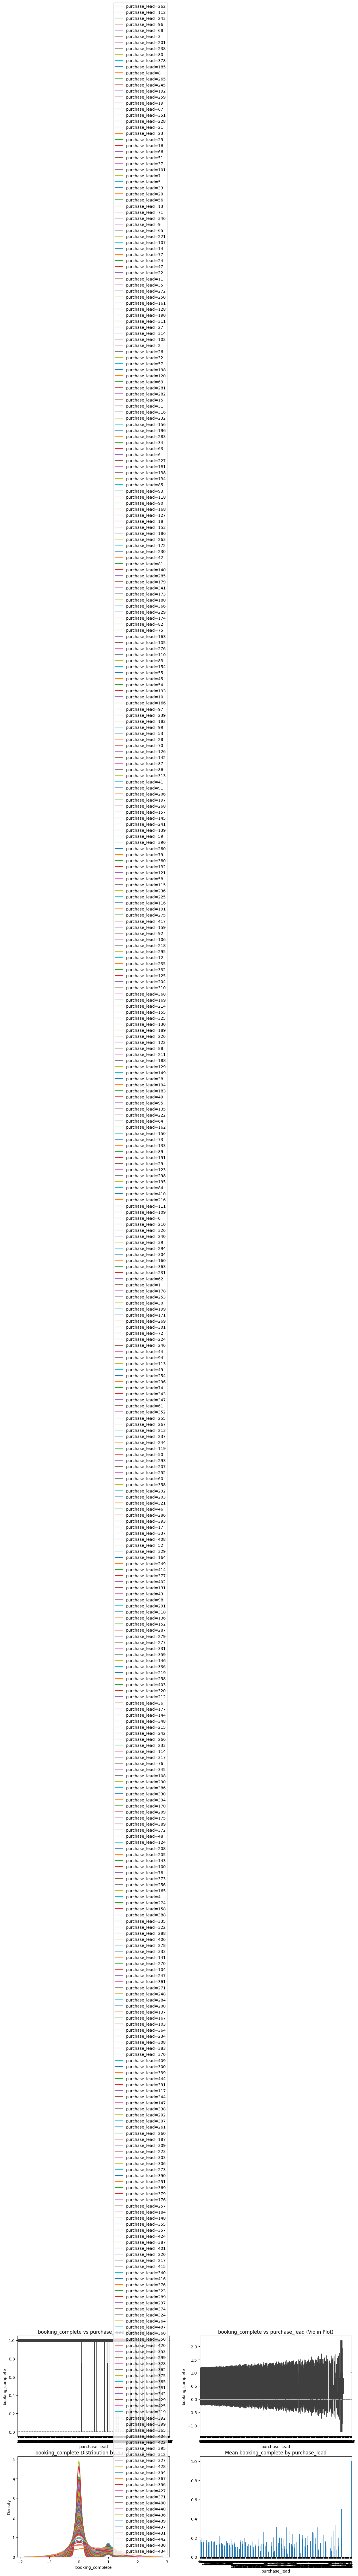

In [ ]:
num_vs_target_analysis(df, 'booking_complete','purchase_lead')

/tmp/ipykernel_25835/368361378.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df[target_col]==val][num_col], label=f'{target_col}={val}')
/tmp/ipykernel_25835/368361378.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df[target_col]==val][num_col], label=f'{target_col}={val}')
/tmp/ipykernel_25835/368361378.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df[target_col]==val][num_col], label=f'{target_col}={val}')
/tmp/ipykernel_25835/368361378.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df[target_col]==val][num_col], label=f'{target_col}={val}')
/tmp/ipykernel_25835/368361378.py:18: UserWarning: Dataset has 0 variance; s

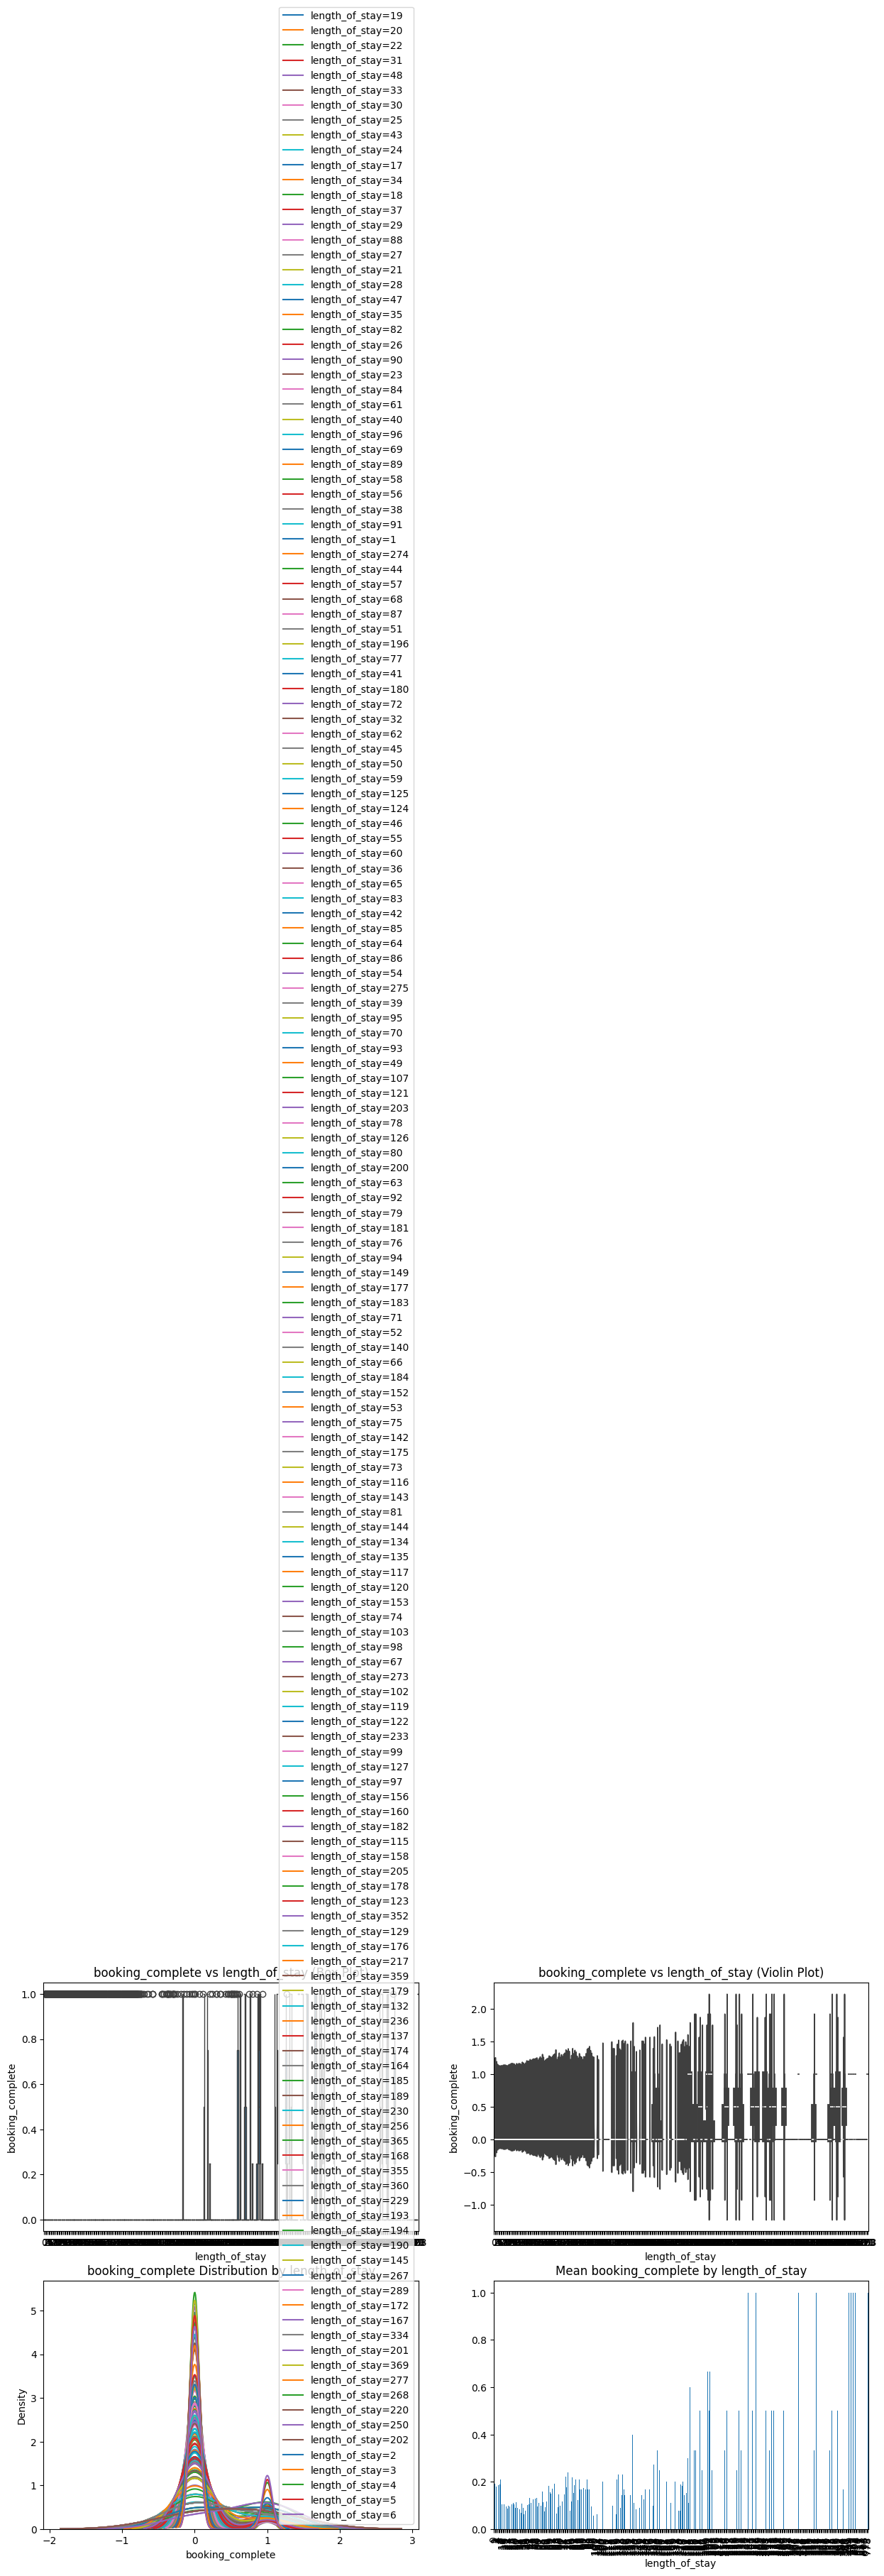

In [ ]:
num_vs_target_analysis(df, 'booking_complete', 'length_of_stay')

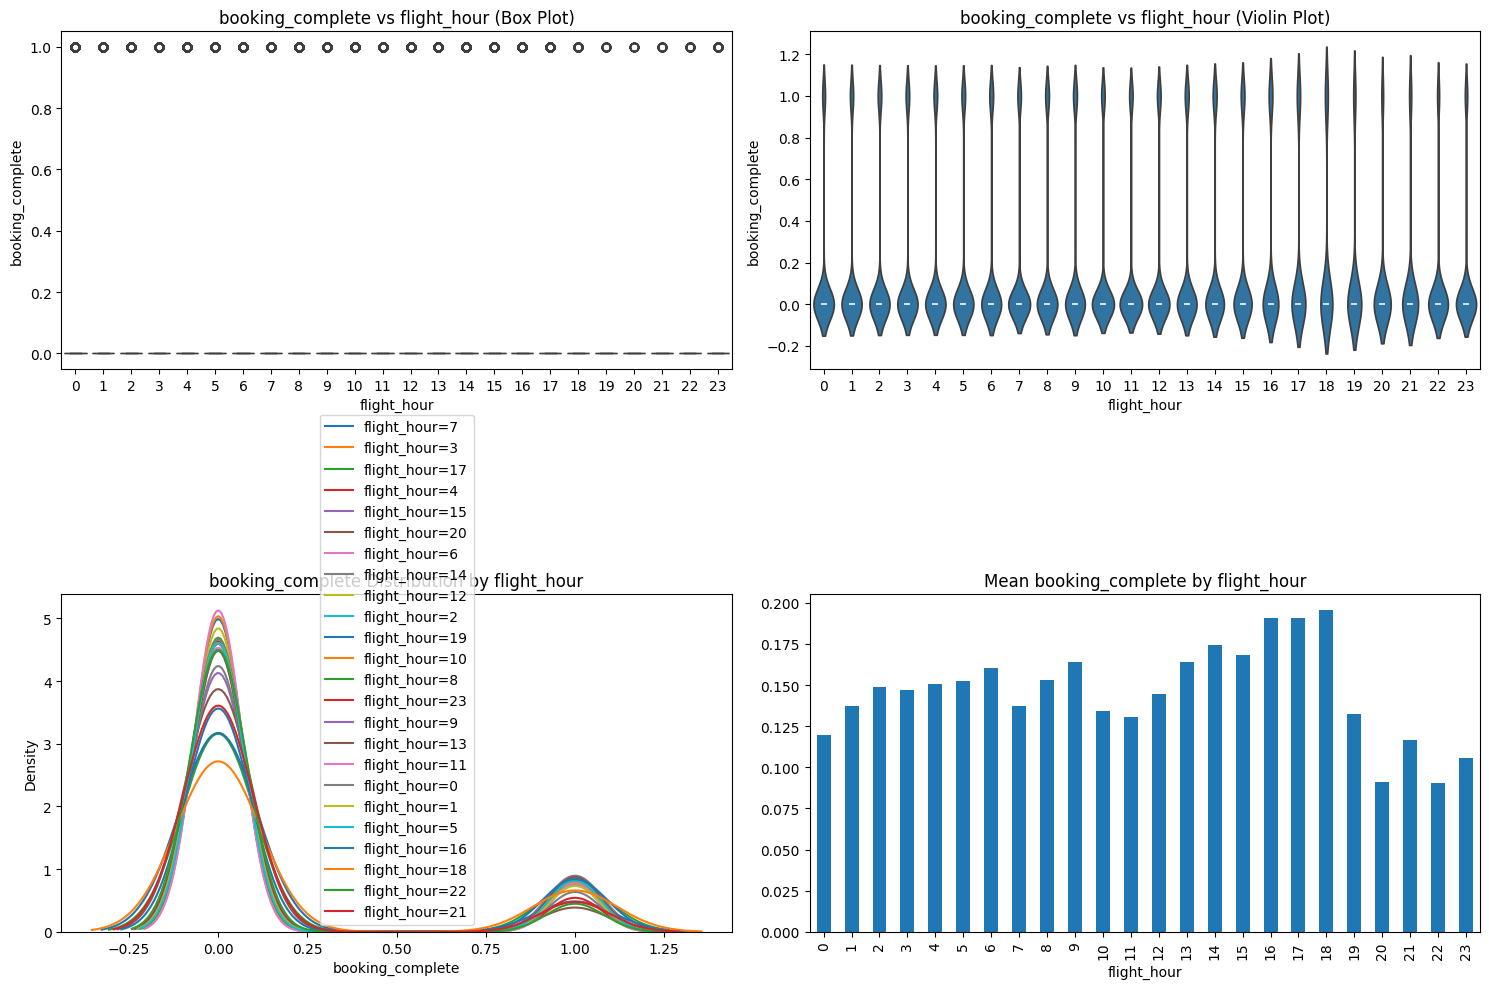

In [ ]:
num_vs_target_analysis(df, 'booking_complete',  'flight_hour')

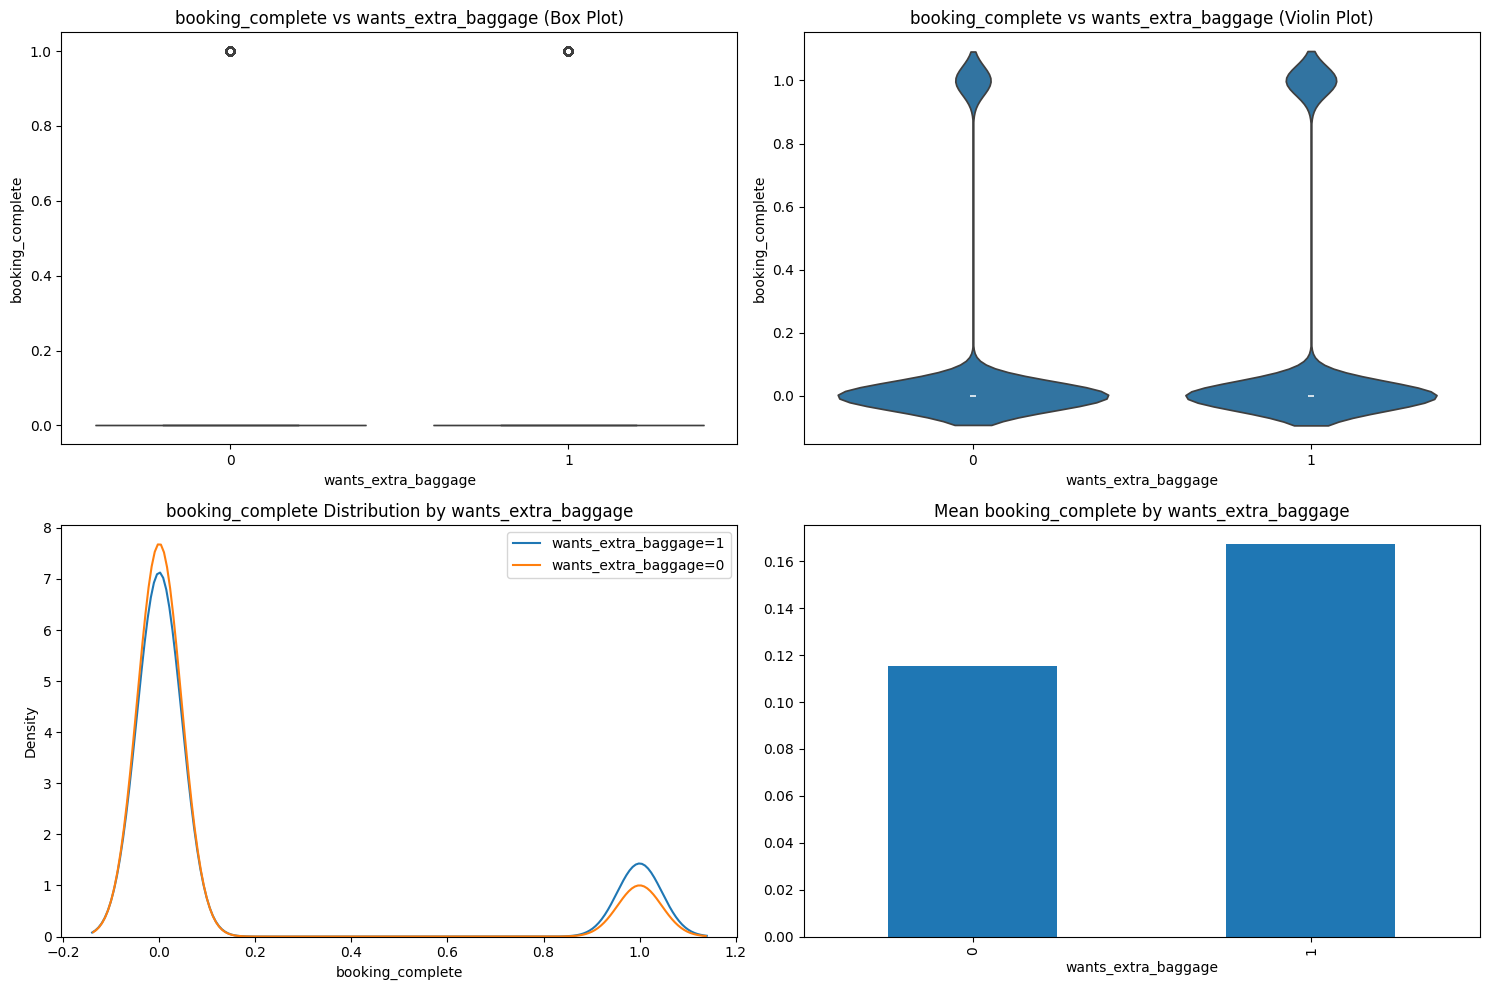

In [ ]:
num_vs_target_analysis(df, 'booking_complete', 'wants_extra_baggage')

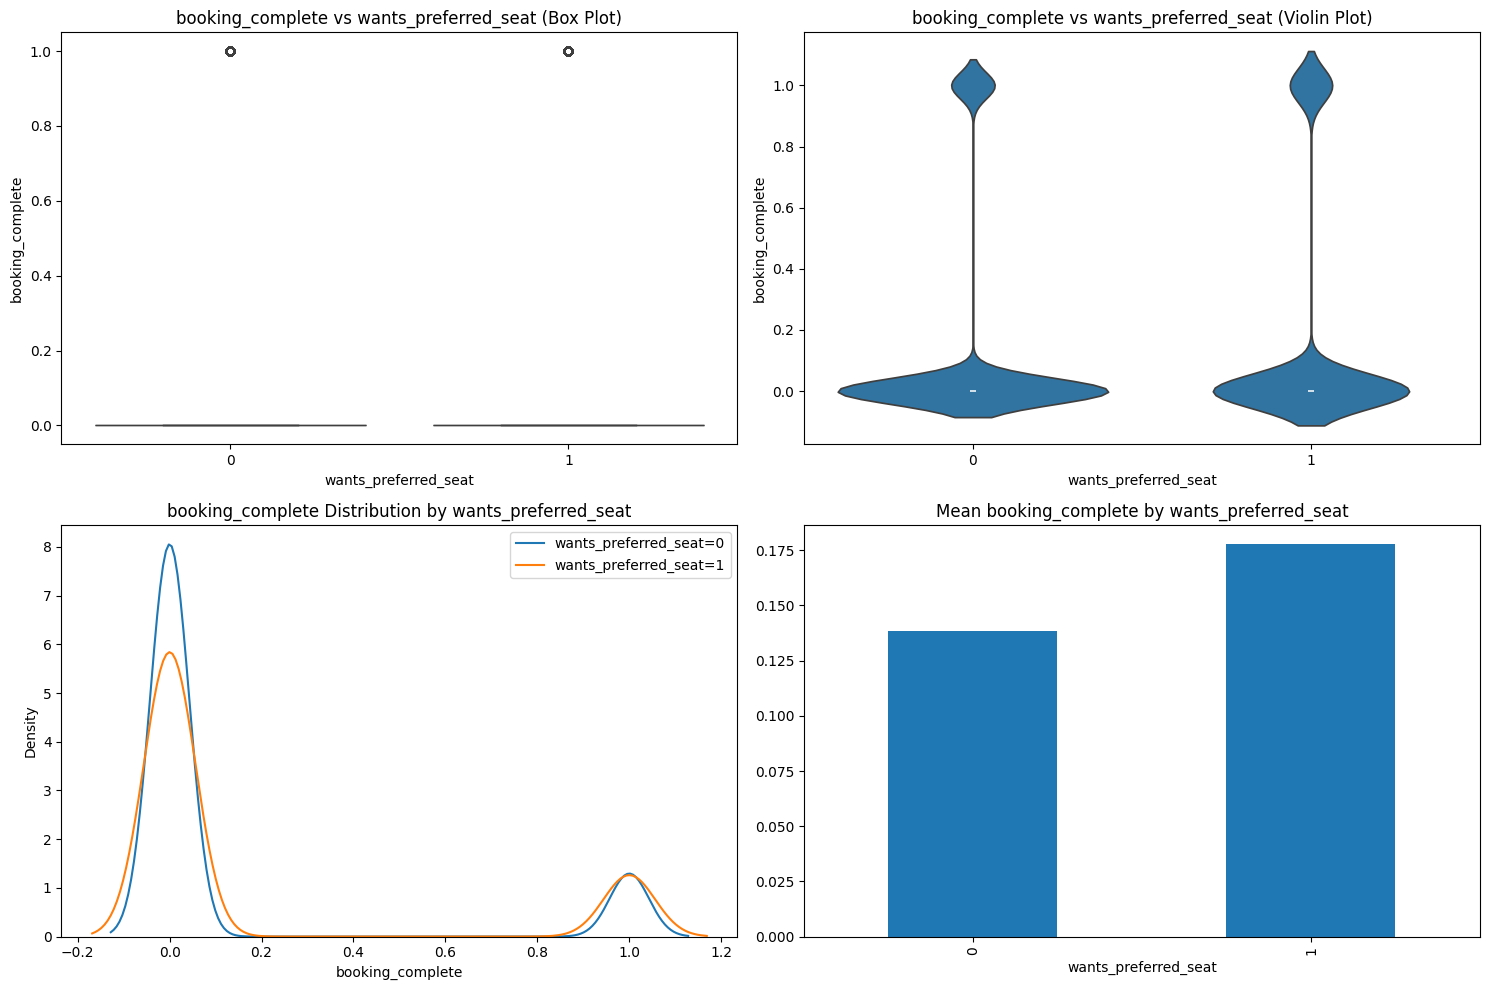

In [ ]:
num_vs_target_analysis(df, 'booking_complete', 'wants_preferred_seat')

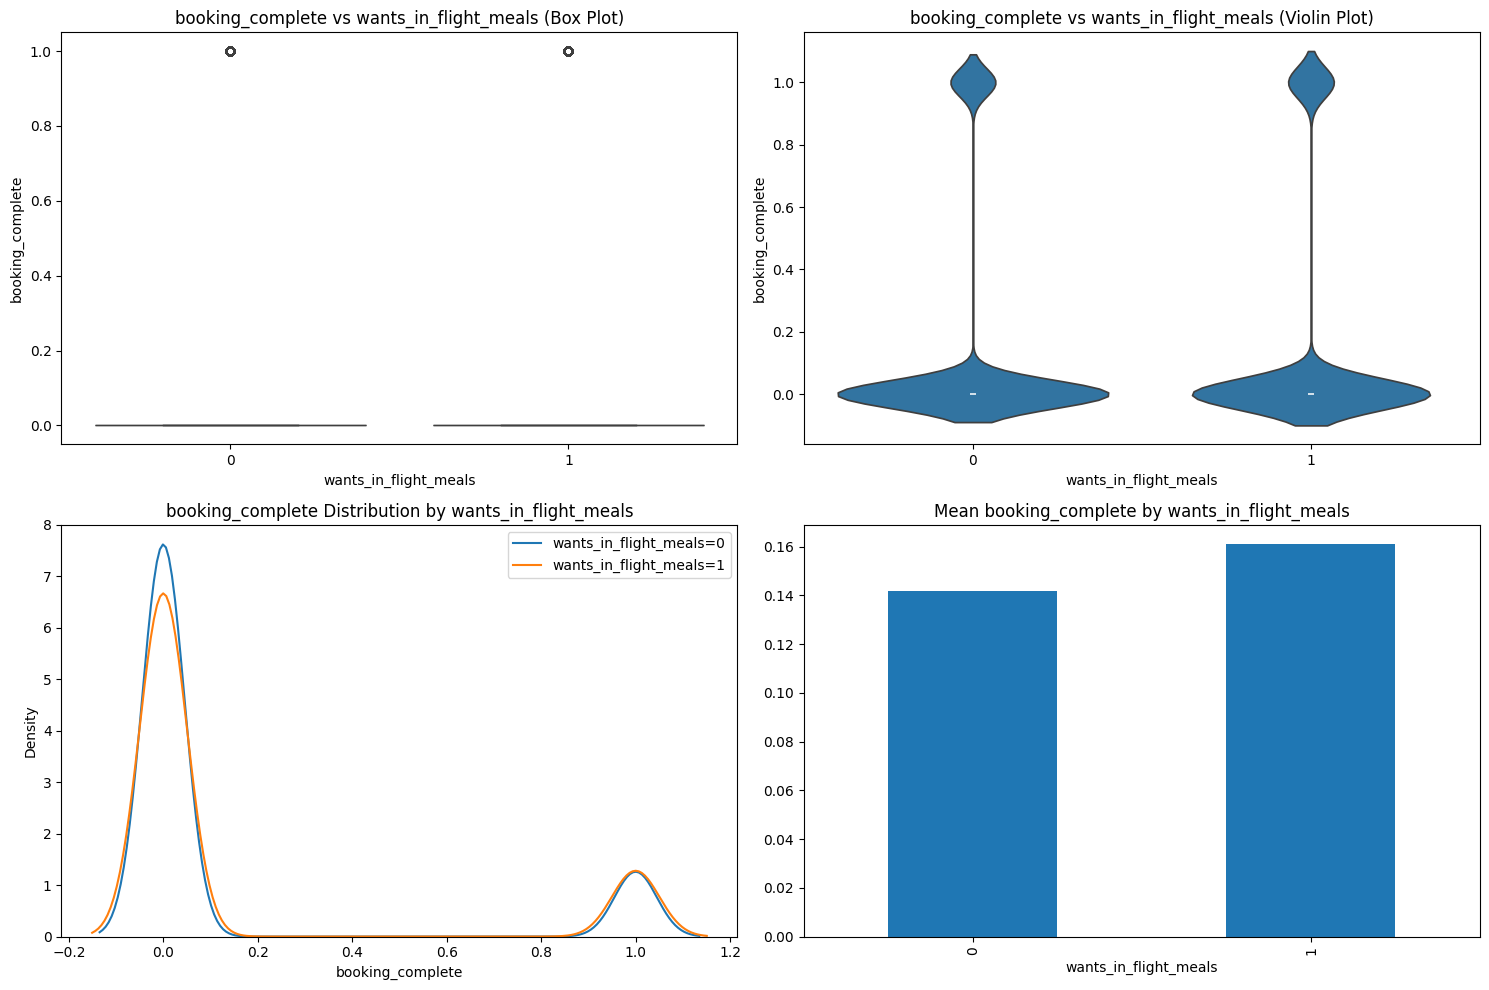

In [ ]:
num_vs_target_analysis(df, 'booking_complete', 'wants_in_flight_meals')

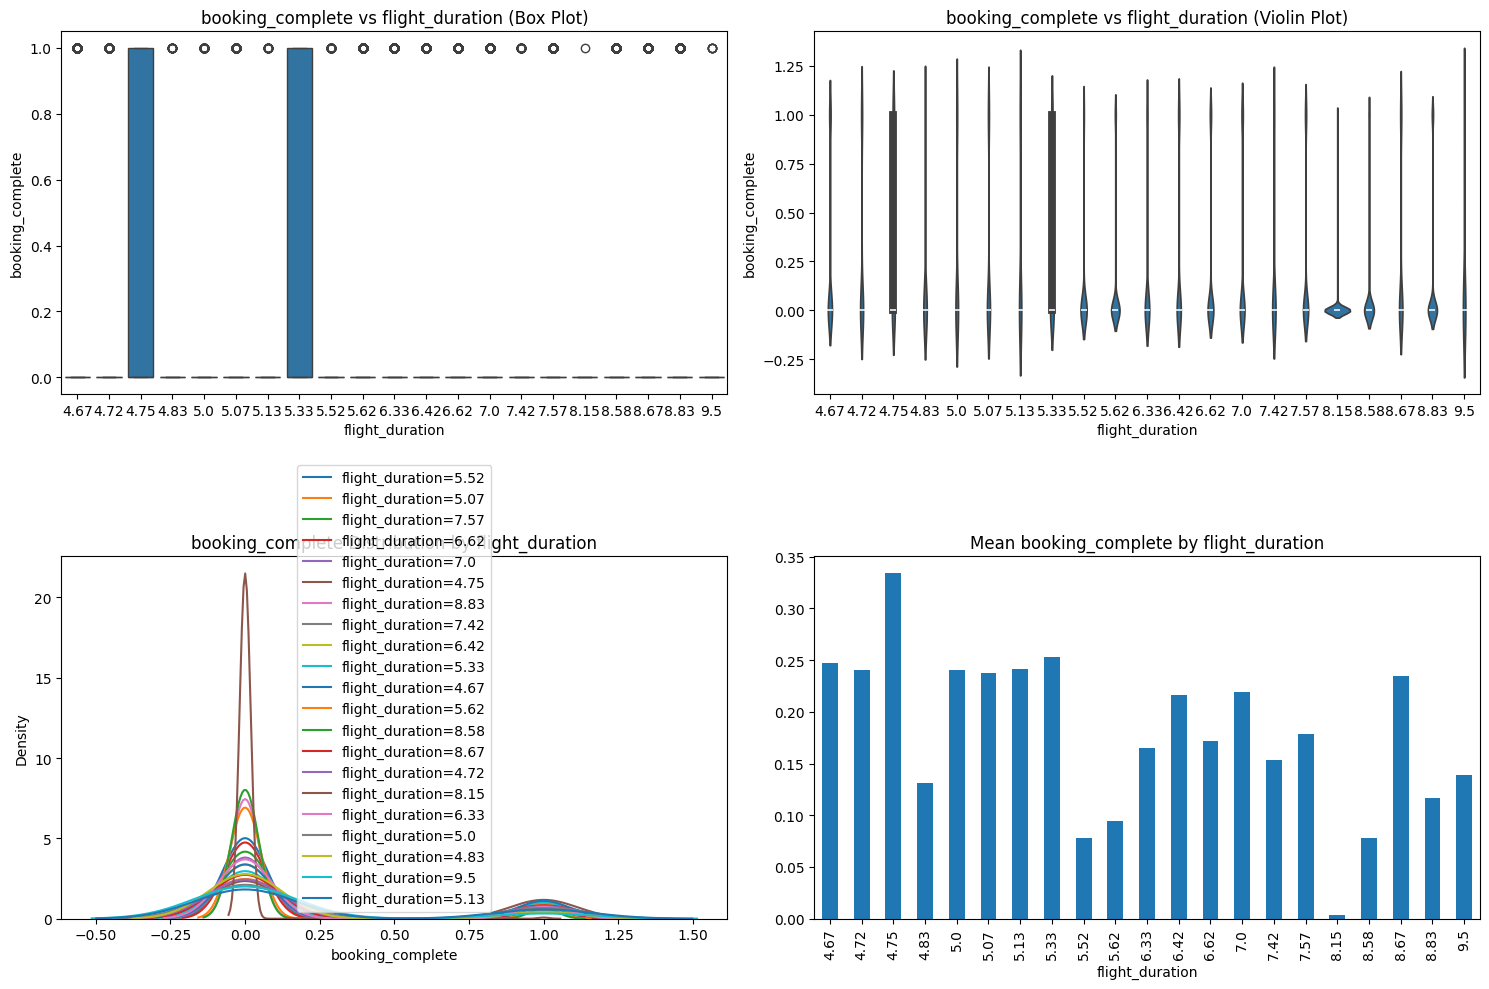

In [ ]:
num_vs_target_analysis(df, 'booking_complete','flight_duration')

/tmp/ipykernel_25835/368361378.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df[target_col]==val][num_col], label=f'{target_col}={val}')
/tmp/ipykernel_25835/368361378.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df[target_col]==val][num_col], label=f'{target_col}={val}')
/tmp/ipykernel_25835/368361378.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


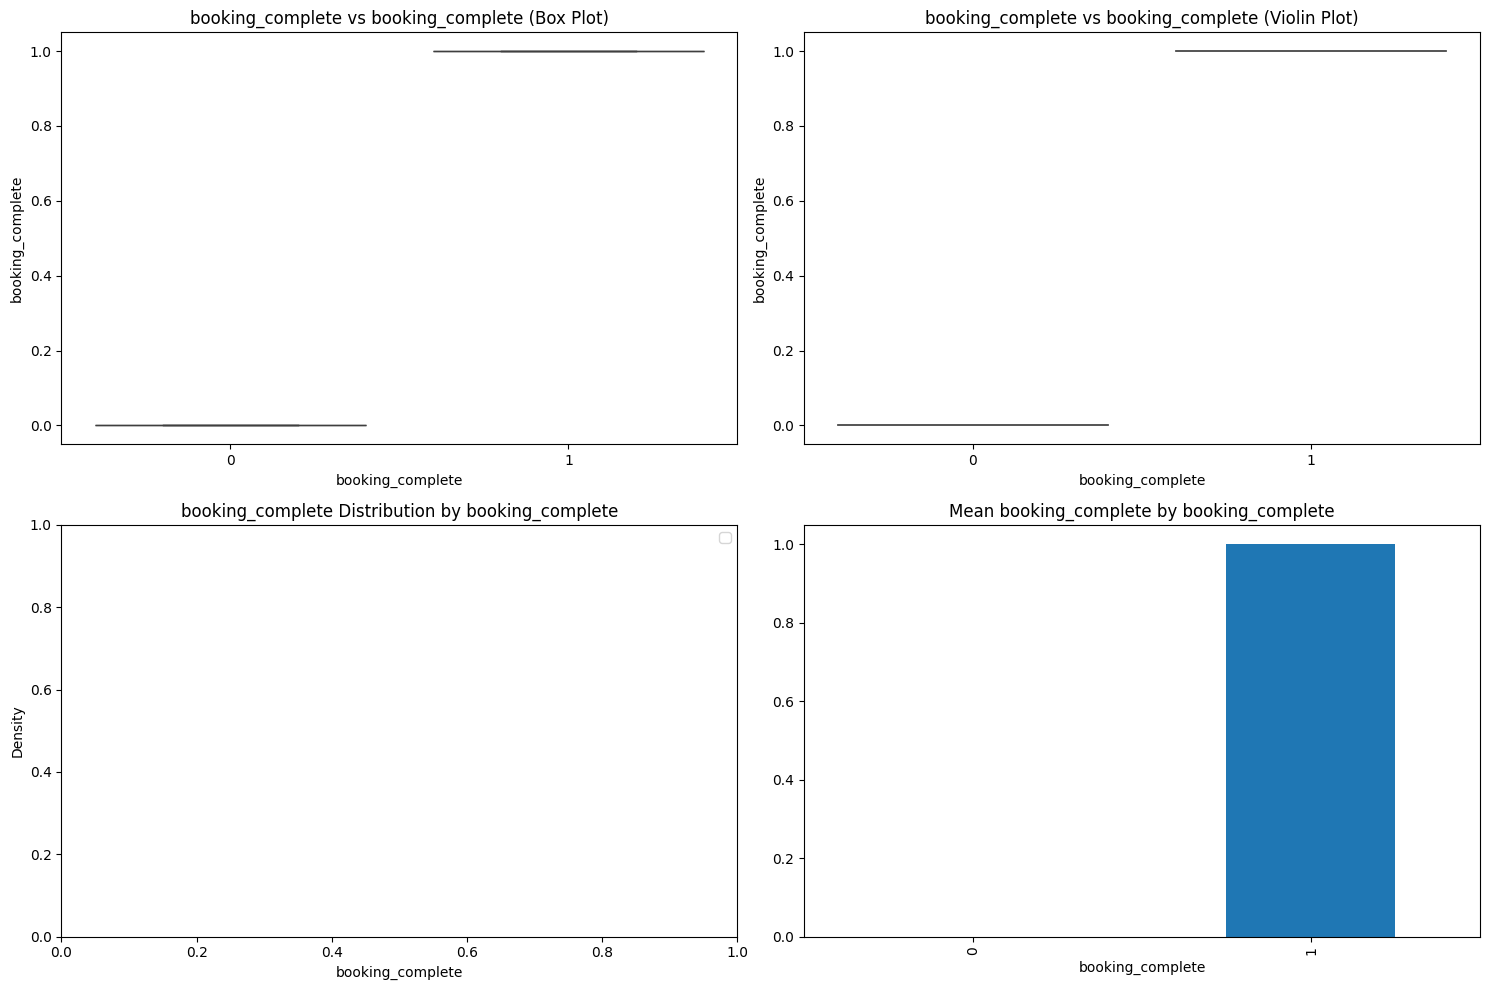

In [ ]:
num_vs_target_analysis(df, 'booking_complete', 'booking_complete')

# Heatmap feature vs feature relation

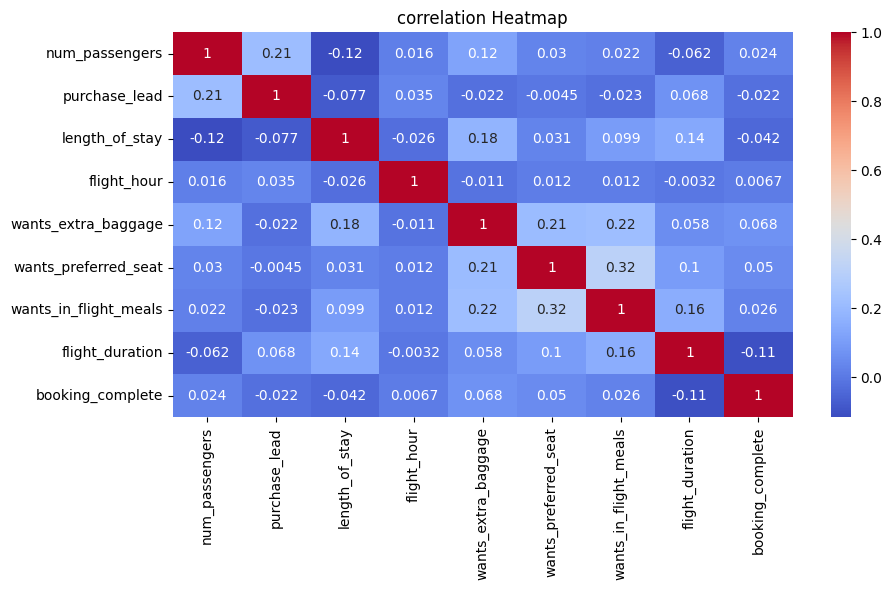

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True),annot=True ,cmap= 'coolwarm')
plt.title('correlation Heatmap')
plt.show()

# Target Column

In [ ]:
df['booking_complete'].value_counts()

,count
booking_complete,
0,41890
1,7391


<Axes: xlabel='booking_complete', ylabel='count'>

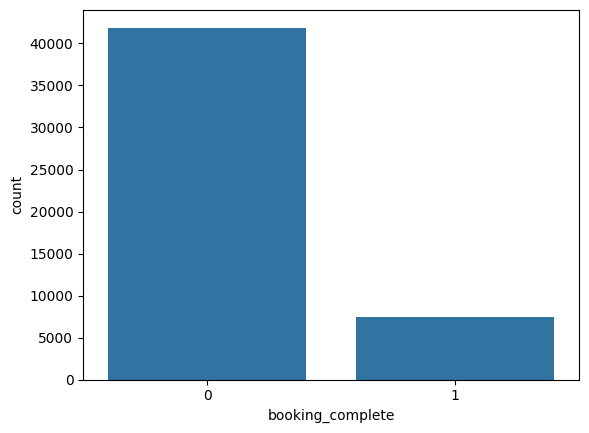

In [ ]:
sns.countplot( x='booking_complete' , data= df)

# Check Skewness

In [ ]:
df.skew(numeric_only=True)

,0
num_passengers,2.688095
purchase_lead,1.656817
length_of_stay,5.296476
flight_hour,0.398141
wants_extra_baggage,-0.714599
wants_preferred_seat,0.895741
wants_in_flight_meals,0.296680
flight_duration,-0.362110
booking_complete,1.960708


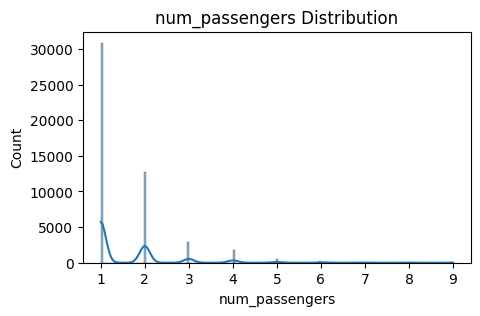

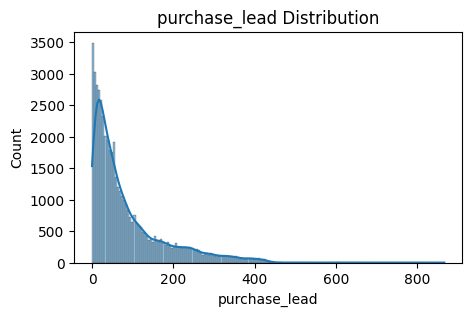

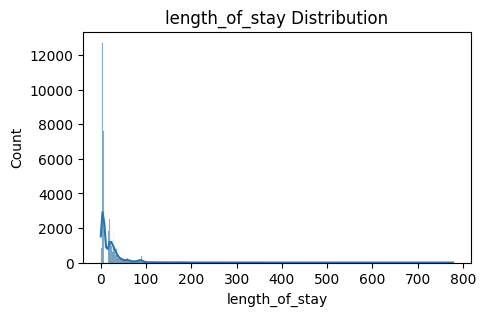

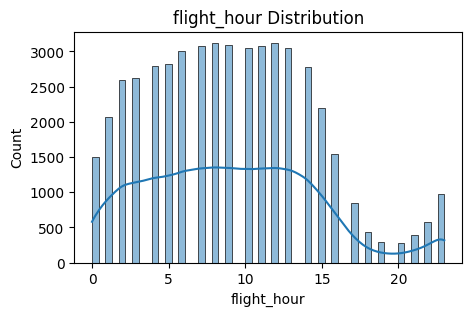

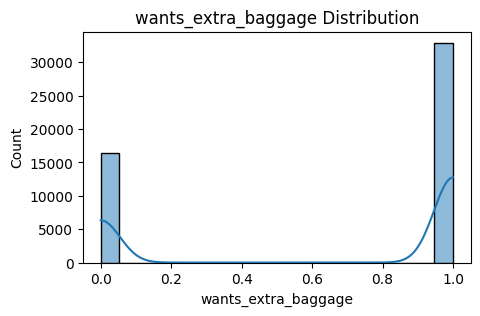

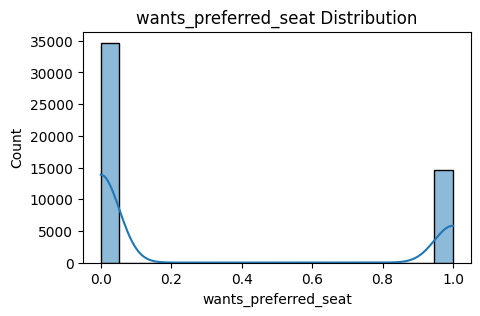

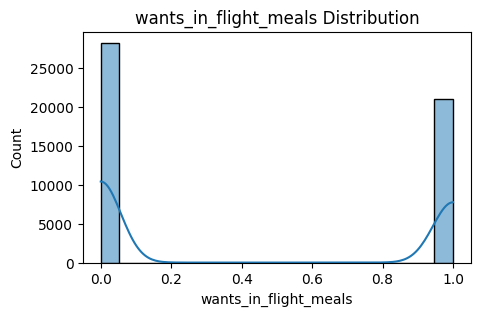

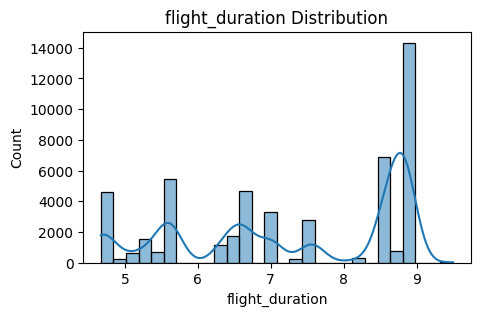

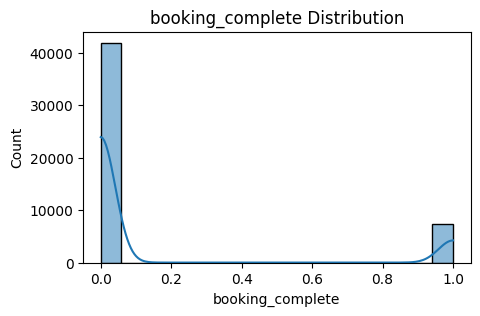

In [ ]:
for col in nos_col:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

# Skew handle




In [ ]:
skewed_cols = ['length_of_stay','num_passengers','purchase_lead']
for i in skewed_cols:
    df[i] = np.log1p(df[i])

# Check Outliers box plot nad IQR method

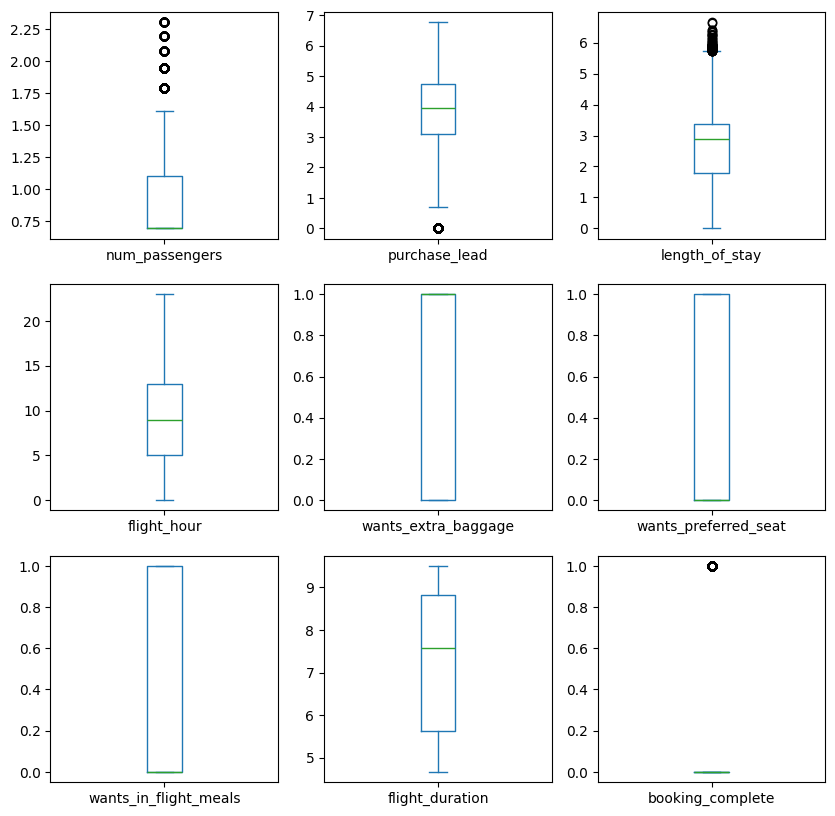

In [ ]:
df[nos_col].plot(kind = 'box' , layout =(3,3),subplots =True,figsize=(10,10))
plt.show()

In [ ]:
for i in nos_col:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 -1.5*IQR
    upper = Q3 +1.5*IQR
    outlier = df[( df[i] < lower ) | ( df[i] > upper )].shape[0]
    print(i,'  ','LOWER :-',lower,'  ','UPPER :-',upper,'   ','Outlier :-',outlier)

num_passengers    LOWER :- 0.0849495183976986    UPPER :- 1.7068099508303565     Outlier :- 1084
purchase_lead    LOWER :- 0.5972208467362434    UPPER :- 7.247411797728438     Outlier :- 365
length_of_stay    LOWER :- -0.5715450719095738    UPPER :- 5.730600371124103     Outlier :- 118
flight_hour    LOWER :- -7.0    UPPER :- 25.0     Outlier :- 0
wants_extra_baggage    LOWER :- -1.5    UPPER :- 2.5     Outlier :- 0
wants_preferred_seat    LOWER :- -1.5    UPPER :- 2.5     Outlier :- 0
wants_in_flight_meals    LOWER :- -1.5    UPPER :- 2.5     Outlier :- 0
flight_duration    LOWER :- 0.8050000000000006    UPPER :- 13.645     Outlier :- 0
booking_complete    LOWER :- 0.0    UPPER :- 0.0     Outlier :- 7391


# handle outlier

In [ ]:
a = ['purchase_lead','num_passengers']
for i in a:

        Q1 = df[i].quantile(0.25)
        Q3 = df[i].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[i] = df[i].clip(lower, upper)

# Apply log1p Transformation & Clip() and Re-check Outliers





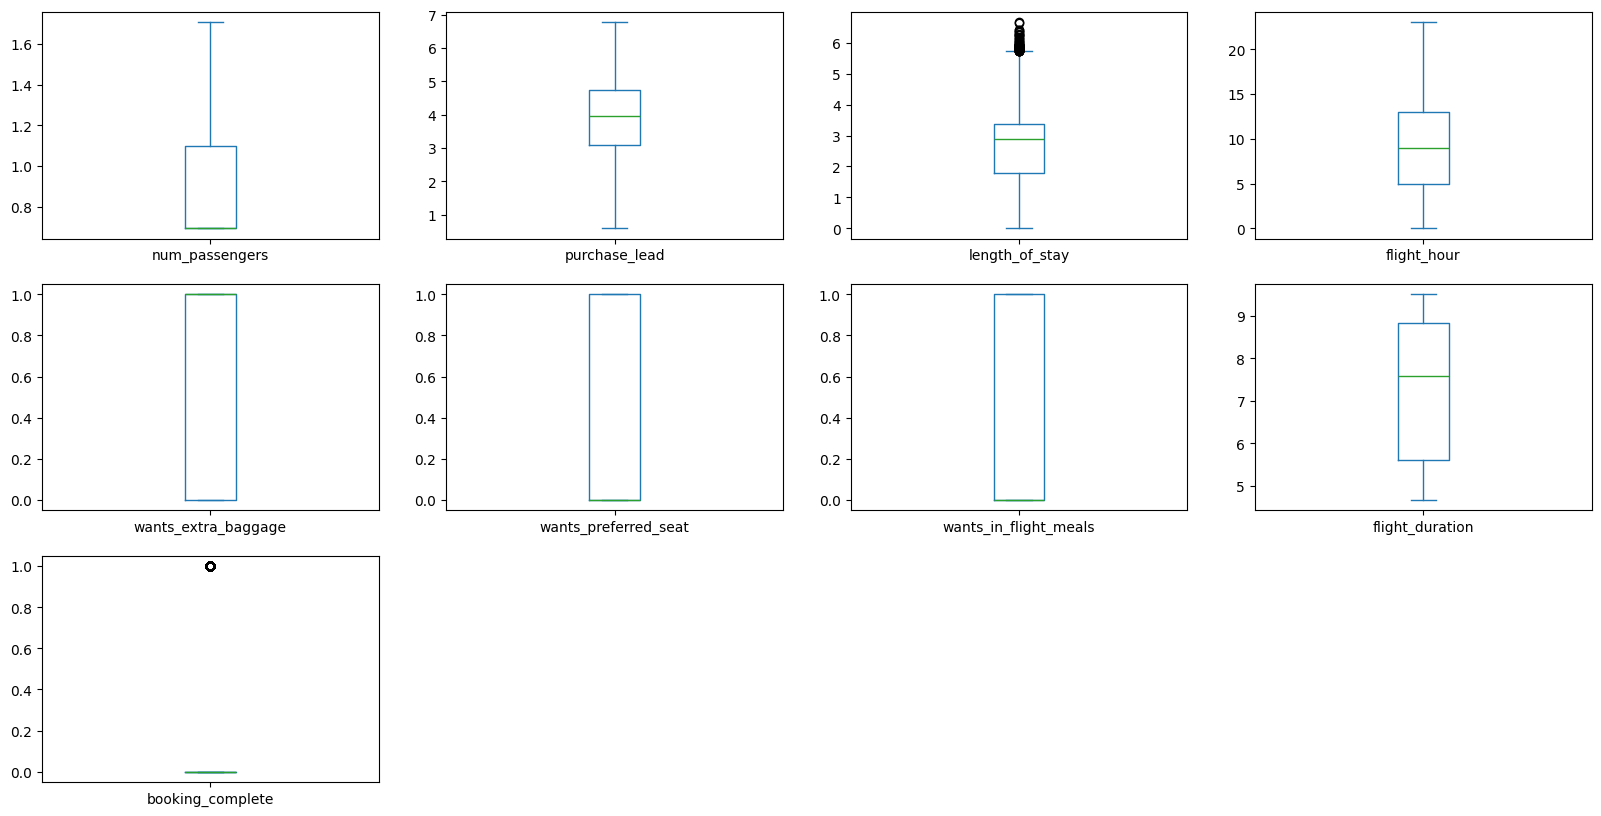

In [ ]:
df[nos_col].plot(kind = 'box' , layout =(3,4),subplots =True,figsize=(20,10))
plt.show()

In [ ]:
for i in nos_col:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 -1.5*IQR
    upper = Q3 +1.5*IQR
    outlier = df[( df[i] < lower ) | ( df[i] > upper )].shape[0]
    print(i,'  ','LOWER :-',lower,'  ','UPPER :-',upper,'   ','Outlier :-',outlier)

num_passengers    LOWER :- 0.0849495183976986    UPPER :- 1.7068099508303565     Outlier :- 0
purchase_lead    LOWER :- 0.5972208467362434    UPPER :- 7.247411797728438     Outlier :- 0
length_of_stay    LOWER :- -0.5715450719095738    UPPER :- 5.730600371124103     Outlier :- 118
flight_hour    LOWER :- -7.0    UPPER :- 25.0     Outlier :- 0
wants_extra_baggage    LOWER :- -1.5    UPPER :- 2.5     Outlier :- 0
wants_preferred_seat    LOWER :- -1.5    UPPER :- 2.5     Outlier :- 0
wants_in_flight_meals    LOWER :- -1.5    UPPER :- 2.5     Outlier :- 0
flight_duration    LOWER :- 0.8050000000000006    UPPER :- 13.645     Outlier :- 0
booking_complete    LOWER :- 0.0    UPPER :- 0.0     Outlier :- 7391


# TARGET vs FEATURE

In [ ]:
corr = df.corr(numeric_only=True)
print(corr['booking_complete'].sort_values(ascending=False))

booking_complete         1.000000
wants_extra_baggage      0.068452
wants_preferred_seat     0.050189
num_passengers           0.026578
wants_in_flight_meals    0.026399
flight_hour              0.006705
purchase_lead           -0.032145
length_of_stay          -0.090787
flight_duration         -0.106529
Name: booking_complete, dtype: float64


In [ ]:
df.duplicated().sum()

np.int64(5)

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

# After Preprocessing: Correlation Heatmap of Features vs Features

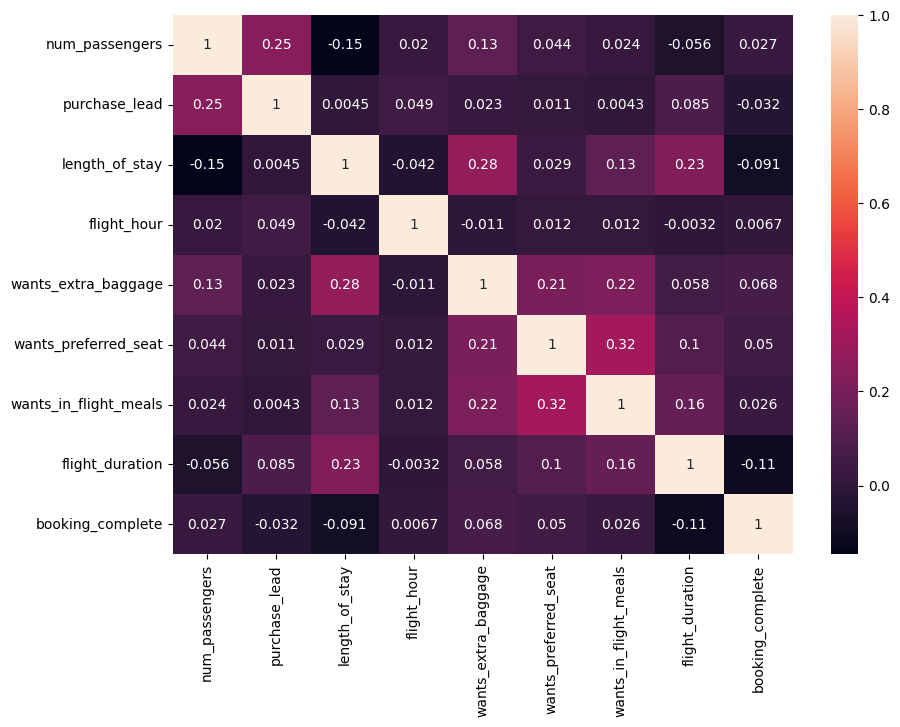

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True) ,annot=True)
plt.show()

# ## After Preprocessing Check eda Part

In [ ]:
df.columns

Index(['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead',
       'length_of_stay', 'flight_hour', 'flight_day', 'route',
       'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals', 'flight_duration', 'booking_complete'],
      dtype='object')

In [ ]:
df.shape

(49276, 14)

In [ ]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,49276.000000,49276.000000,49276.000000,49276.000000,49276.000000,49276.000000,49276.000000,49276.000000,49276.000000
mean,0.892987,3.849463,2.630972,9.070724,0.668236,0.295661,0.426638,7.280093,0.149992
std,0.288168,1.220929,1.005011,5.413212,0.470851,0.456344,0.494594,1.496402,0.357067
min,0.693147,0.597221,0.000000,0.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,0.693147,3.091042,1.791759,5.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,0.693147,3.951244,2.890372,9.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,1.098612,4.753590,3.367296,13.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,1.706810,6.766192,6.658011,23.000000,1.000000,1.000000,1.000000,9.500000,1.000000


In [ ]:
df.isna().sum()

,0
num_passengers,0
sales_channel,0
trip_type,0
purchase_lead,0
length_of_stay,0
flight_hour,0
flight_day,0
route,0
booking_origin,0
wants_extra_baggage,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# The cleaned dataset was saved locally for further use and analysis.

In [ ]:
from google.colab import files

df.to_csv("Cleaned_data_Customer_Booking_British_Airways.csv", index=False)

files.download("Cleaned_data_Customer_Booking_British_Airways.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Model Build

In [18]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [19]:
df1 = pd.read_csv(r"/content/Cleaned_data_Customer_Booking_British_Airways.csv")
df1

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,1.098612,Internet,RoundTrip,5.572154,2.995732,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,0.693147,Internet,RoundTrip,4.727388,3.044522,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,1.098612,Internet,RoundTrip,5.497168,3.135494,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,0.693147,Internet,RoundTrip,4.574711,3.465736,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,1.098612,Internet,RoundTrip,4.234107,3.135494,15,Wed,AKLDEL,India,1,0,1,5.52,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49271,1.098612,Internet,RoundTrip,3.332205,1.945910,9,Sat,PERPNH,Australia,1,0,1,5.62,0
49272,0.693147,Internet,RoundTrip,4.718499,1.945910,4,Sun,PERPNH,Australia,0,0,0,5.62,0
49273,0.693147,Internet,RoundTrip,3.218876,1.945910,22,Sat,PERPNH,Australia,0,0,1,5.62,0
49274,0.693147,Internet,RoundTrip,2.772589,1.945910,11,Mon,PERPNH,Australia,1,0,1,5.62,0


# Feature Engineering

In [20]:
df1['total_extras'] = df1['wants_extra_baggage'] + df1['wants_preferred_seat'] + df1['wants_in_flight_meals']

In [21]:
df1['total_extras'].value_counts()

,count
total_extras,
1,17961
2,12360
0,10342
3,8613


In [22]:
df1['is_weekend'] = df1['flight_day'].isin(['Sat','Sun']).astype(int)

In [23]:
def hour_category(h):
    if 5 <= h < 12: return 'Morning'
    elif 12 <= h < 17: return 'Afternoon'
    elif 17 <= h < 21: return 'Evening'
    else: return 'Night'
df1['flight_hour_category'] = df1['flight_hour'].apply(hour_category)

In [24]:
df1['is_last_minute'] = (df1['purchase_lead'] < df1['purchase_lead'].quantile(0.25)).astype(int)

In [25]:
df1['is_round_trip'] = (df1['trip_type'] == 'RoundTrip').astype(int)

In [26]:
df1

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,total_extras,is_weekend,flight_hour_category,is_last_minute,is_round_trip
0,1.098612,Internet,RoundTrip,5.572154,2.995732,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0,1,1,Morning,0,1
1,0.693147,Internet,RoundTrip,4.727388,3.044522,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0,0,1,Night,0,1
2,1.098612,Internet,RoundTrip,5.497168,3.135494,17,Wed,AKLDEL,India,1,1,0,5.52,0,2,0,Evening,0,1
3,0.693147,Internet,RoundTrip,4.574711,3.465736,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0,1,1,Night,0,1
4,1.098612,Internet,RoundTrip,4.234107,3.135494,15,Wed,AKLDEL,India,1,0,1,5.52,0,2,0,Afternoon,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49271,1.098612,Internet,RoundTrip,3.332205,1.945910,9,Sat,PERPNH,Australia,1,0,1,5.62,0,2,1,Morning,0,1
49272,0.693147,Internet,RoundTrip,4.718499,1.945910,4,Sun,PERPNH,Australia,0,0,0,5.62,0,0,1,Night,0,1
49273,0.693147,Internet,RoundTrip,3.218876,1.945910,22,Sat,PERPNH,Australia,0,0,1,5.62,0,1,1,Night,0,1
49274,0.693147,Internet,RoundTrip,2.772589,1.945910,11,Mon,PERPNH,Australia,1,0,1,5.62,0,2,0,Morning,1,1


In [27]:
x = df1.drop(['booking_complete'],axis=1)
y = df1['booking_complete']

# Train Test Split

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

In [29]:
print("Train :", x_train.shape)

print("Test :", x_test.shape)

Train : (39420, 18)
Test : (9856, 18)


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler ,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin


In [31]:
cat_col = x.select_dtypes(include=['object']).columns
nos_col = x.select_dtypes(include=['int64','float64']).columns
nos_col

Index(['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour',
       'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals',
       'flight_duration', 'total_extras', 'is_weekend', 'is_last_minute',
       'is_round_trip'],
      dtype='object')

In [32]:
cat_col

Index(['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin',
       'flight_hour_category'],
      dtype='object')

In [33]:
for col in cat_col:
    print(col,' ',x[col].unique())

sales_channel   ['Internet' 'Mobile']
trip_type   ['RoundTrip' 'CircleTrip' 'OneWay']
flight_day   ['Sat' 'Wed' 'Thu' 'Mon' 'Sun' 'Tue' 'Fri']
route   ['AKLDEL' 'AKLHGH' 'AKLHND' 'AKLICN' 'AKLKIX' 'AKLKTM' 'AKLKUL' 'AKLMRU'
 'AKLPEK' 'AKLPVG' 'AKLTPE' 'AORICN' 'AORKIX' 'AORKTM' 'AORMEL' 'BBIMEL'
 'BBIOOL' 'BBIPER' 'BBISYD' 'BDOCTS' 'BDOCTU' 'BDOHGH' 'BDOICN' 'BDOIKA'
 'BDOKIX' 'BDOMEL' 'BDOOOL' 'BDOPEK' 'BDOPER' 'BDOPUS' 'BDOPVG' 'BDOSYD'
 'BDOTPE' 'BDOXIY' 'BKICKG' 'BKICTS' 'BKICTU' 'BKIHND' 'BKIICN' 'BKIKIX'
 'BKIKTM' 'BKIMEL' 'BKIMRU' 'BKIOOL' 'BKIPEK' 'BKIPER' 'BKIPUS' 'BKIPVG'
 'BKISYD' 'BKIXIY' 'BLRICN' 'BLRMEL' 'BLRPER' 'BLRSYD' 'BOMMEL' 'BOMOOL'
 'BOMPER' 'BOMSYD' 'BTJJED' 'BTUICN' 'BTUPER' 'BTUSYD' 'BTUWUH' 'BWNCKG'
 'BWNDEL' 'BWNHGH' 'BWNIKA' 'BWNKTM' 'BWNMEL' 'BWNOOL' 'BWNPER' 'BWNSYD'
 'BWNTPE' 'CANDEL' 'CANIKA' 'CANMEL' 'CANMRU' 'CANOOL' 'CANPER' 'CANSYD'
 'CCUMEL' 'CCUMRU' 'CCUOOL' 'CCUPER' 'CCUSYD' 'CCUTPE' 'CEBMEL' 'CEBOOL'
 'CEBPER' 'CEBSYD' 'CGKCKG' 'CGKCTS' 'CGKCTU' 

In [34]:
freq_cols = ['route','booking_origin']
nominal_cols = ['sales_channel','trip_type','flight_day','flight_hour_category']

In [35]:
cat_col

Index(['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin',
       'flight_hour_category'],
      dtype='object')

In [36]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        self.freq_maps = {}
        for col in X.columns:
            self.freq_maps[col] = X[col].value_counts().to_dict()
        return self

    def transform(self, X):
        X_transformed = X.copy()
        for col in X.columns:
            X_transformed[col] = X[col].map(self.freq_maps[col]).fillna(0)
        return X_transformed

In [37]:
nos_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

freq_pipeline = Pipeline([
    ('freq', FrequencyEncoder())
])

nominal_pipeline = Pipeline([
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'))
])

In [38]:
preprocessor = ColumnTransformer([
    ('num',nos_pipeline,nos_col),
    ('freq', freq_pipeline, freq_cols),
    ('nom',nominal_pipeline,nominal_cols)
])


<Axes: xlabel='booking_complete', ylabel='count'>

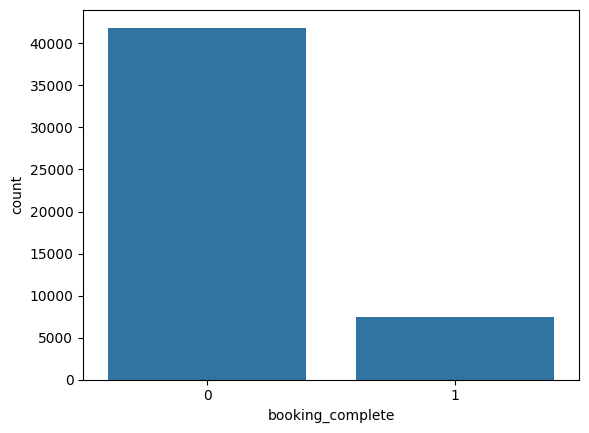

In [39]:
sns.countplot( x='booking_complete',data=df1)

In [40]:
df1['booking_complete'].value_counts(normalize=True)*100

,proportion
booking_complete,
0,85.000812
1,14.999188


In [41]:
y_train.value_counts()

,count
booking_complete,
0,33507
1,5913


In [42]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE



smote = SMOTE(
    sampling_strategy=0.8,
    random_state=42,
    k_neighbors=5
)

In [43]:

import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)

In [44]:
X_train_pre = preprocessor.fit_transform(x_train)

X_smote, y_smote = smote.fit_resample(X_train_pre, y_train)

print(y_train.value_counts())
print(y_smote.value_counts())

booking_complete
0    33507
1     5913
Name: count, dtype: int64
booking_complete
0    33507
1    26805
Name: count, dtype: int64


In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix


models = {


    'knn': KNeighborsClassifier(),

    'RandomForestClassifier': RandomForestClassifier(

    ),

    'DecisionTreeClassifier': DecisionTreeClassifier(

    ),

    'XGBClassifier': XGBClassifier(

    )
}

for name, model in models.items():

    pipeline = ImbPipeline([
        ('preprocessing', preprocessor),
        ('smote', smote),
        ('model', model)
    ])

    cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
    scores = cross_val_score(pipeline,x_train,y_train,cv=cv,scoring='f1')
    print(f'{name} F1 score : {scores.mean():.4f}')

knn F1 score : 0.3706
RandomForestClassifier F1 score : 0.1745
DecisionTreeClassifier F1 score : 0.2800
XGBClassifier F1 score : 0.2175


# Hyperparameter Tuning

In [85]:
from sklearn.model_selection import RandomizedSearchCV
pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('smote', smote),
    ('model', RandomForestClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [3,4, 5,6,7],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2'],
    'model__bootstrap': [True, False],
    'model__class_weight': ['balanced', None]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=50,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1
)

random_search.fit(x_train, y_train)

print("Best F1 Score:", random_search.best_score_)
print("Best Parameters:")
print(random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best F1 Score: 0.36099077742627317
Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 5, 'model__class_weight': 'balanced', 'model__bootstrap': True}


In [48]:
best_model = random_search.best_estimator_

y_test_pred = best_model.predict(x_test)

print("\n--- Test Set Metrics ---")
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))

print("\n--- Full Classification Report ---")
print(classification_report(y_test, y_test_pred))

NameError: name 'random_search' is not defined

#  GradientBoostingClassifier

In [87]:


pipeline_gb = ImbPipeline([
    ('preprocessing', preprocessor),
    ('smote', smote),
    ('model', GradientBoostingClassifier(random_state=42))
])

param_grid_gb = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [2, 3, 4, 5],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__max_features': ['sqrt', 'log2', None]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_search_gb = RandomizedSearchCV(
    estimator=pipeline_gb,
    param_distributions=param_grid_gb,
    n_iter=20,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=0
)

random_search_gb.fit(x_train, y_train)

print("Best F1 Score (GradientBoosting):", random_search_gb.best_score_)
print("Best Parameters:")
print(random_search_gb.best_params_)

Best F1 Score (GradientBoosting): 0.27579344552083546
Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 2, 'model__learning_rate': 0.01}


# XGBClassifier

In [88]:

pipeline_xgb = ImbPipeline([
    ('preprocessing', preprocessor),
    ('smote', smote),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

param_grid_xgb = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [2, 3, 4, 5, 6],
    'model__min_child_weight': [1, 3, 5],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__gamma': [0, 0.1, 0.3]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_search_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=param_grid_xgb,
    n_iter=20,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=0
)

random_search_xgb.fit(x_train, y_train)

print("Best F1 Score (XGBoost):", random_search_xgb.best_score_)
print("Best Parameters:")
print(random_search_xgb.best_params_)

Best F1 Score (XGBoost): 0.3226663825592492
Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_child_weight': 3, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 0.1, 'model__colsample_bytree': 0.6}


In [56]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print("scale_pos_weight:", scale_pos_weight)



pipeline_xgb_v2 = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

param_grid_xgb_v2 = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.02, 0.03, 0.05, 0.07, 0.1],
    'model__max_depth': [4, 5, 6],
    'model__min_child_weight': [5, 7, 10],
    'model__subsample': [0.6, 0.7, 0.8],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__gamma': [0.2, 0.3, 0.5],
    'model__scale_pos_weight': [4, 4.5, 5, 5.5, 5.67, 6, 6.5, 7]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_xgb_v2 = RandomizedSearchCV(
    estimator=pipeline_xgb_v2,
    param_distributions=param_grid_xgb_v2,
    n_iter=60,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=0
)

random_search_xgb_v2.fit(x_train, y_train)

print("Best F1 Score (XGBoost v2):", random_search_xgb_v2.best_score_)
print("Best Parameters:")
print(random_search_xgb_v2.best_params_)

scale_pos_weight: 5.666666666666667
Best F1 Score (XGBoost v2): 0.438276644898657
Best Parameters:
{'model__subsample': 0.7, 'model__scale_pos_weight': 4, 'model__n_estimators': 300, 'model__min_child_weight': 7, 'model__max_depth': 6, 'model__learning_rate': 0.03, 'model__gamma': 0.2, 'model__colsample_bytree': 0.6}


In [57]:

best_xgb_model = random_search_xgb_v2.best_estimator_

y_test_pred = best_xgb_model.predict(x_test)

print("--- Test Set Metrics (XGBoost) ---")
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))

print("\n--- Full Classification Report ---")
print(classification_report(y_test, y_test_pred))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_test_pred))

--- Test Set Metrics (XGBoost) ---
Precision: 0.337151584574265
Recall: 0.5974289580514208
F1 Score: 0.4310471076397364

--- Full Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.79      0.85      8378
           1       0.34      0.60      0.43      1478

    accuracy                           0.76      9856
   macro avg       0.63      0.70      0.64      9856
weighted avg       0.83      0.76      0.79      9856


--- Confusion Matrix ---
[[6642 1736]
 [ 595  883]]


In [58]:

# Train in predict
y_train_pred = best_xgb_model.predict(x_train)

print("--- Train Set Metrics ---")
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1 Score:", f1_score(y_train, y_train_pred))

print("\n--- Test Set Metrics ")
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))

--- Train Set Metrics ---
Precision: 0.390954678777557
Recall: 0.6987992558768814
F1 Score: 0.5013954617158112

--- Test Set Metrics 
Precision: 0.337151584574265
Recall: 0.5974289580514208
F1 Score: 0.4310471076397364


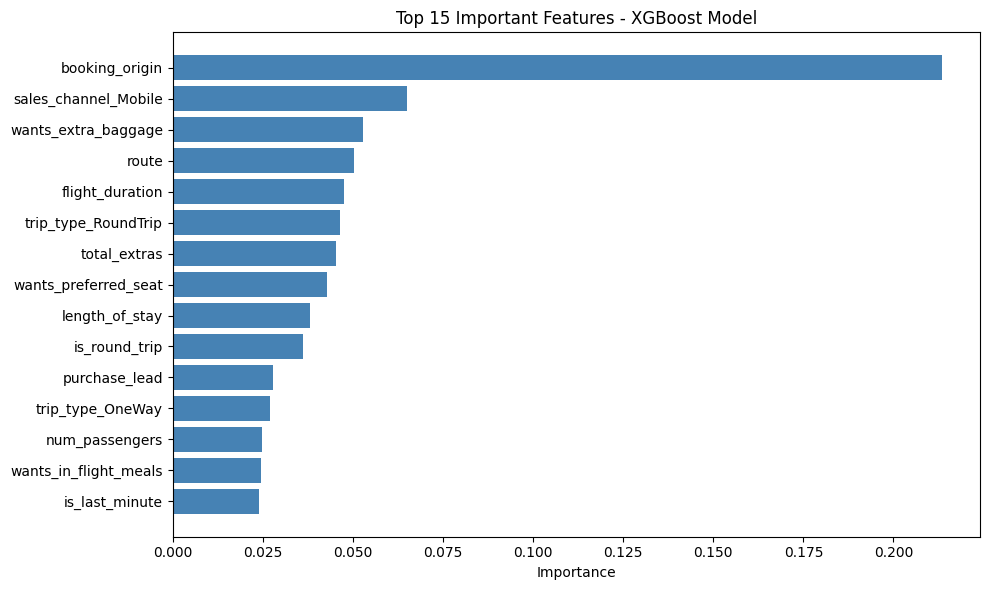

In [63]:



best_model = random_search_xgb_v2.best_estimator_


onehot_cols = best_model.named_steps['preprocessing'].named_transformers_['nom'].named_steps['onehot'].get_feature_names_out(nominal_cols)


all_features = list(nos_col) + list(freq_cols) + list(onehot_cols)

imp_values = best_model.named_steps['model'].feature_importances_

feat_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': imp_values
})

feat_df = feat_df.sort_values(by='Importance', ascending=False)

top_features = feat_df.head(15)


plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
plt.xlabel("Importance")
plt.title("Top 15 Important Features - XGBoost Model")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [64]:

best_model = random_search_xgb_v2.best_estimator_

probs = best_model.predict_proba(x_test)[:, 1]


print(f"{'Threshold':<10} {'Precision':<10} {'Recall':<10} {'F1 Score':<10}")
print("-" * 45)

best_f1 = 0
best_threshold = 0.5

for t in np.arange(0.20, 0.75, 0.05):
    preds = (probs >= t).astype(int)
    p = precision_score(y_test, preds)
    r = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"{t:<10.2f} {p:<10.3f} {r:<10.3f} {f1:<10.3f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")
print(f"Best F1 Score: {best_f1:.4f}")

Threshold  Precision  Recall     F1 Score  
---------------------------------------------
0.20       0.217      0.928      0.352     
0.25       0.239      0.889      0.377     
0.30       0.258      0.846      0.396     
0.35       0.278      0.800      0.412     
0.40       0.295      0.735      0.421     
0.45       0.313      0.671      0.427     
0.50       0.337      0.597      0.431     
0.55       0.364      0.520      0.429     
0.60       0.390      0.413      0.401     
0.65       0.429      0.309      0.359     
0.70       0.457      0.189      0.267     

Best Threshold: 0.50
Best F1 Score: 0.4310


In [65]:
import joblib
from google.colab import files

# best model save kela
best_model = random_search_xgb_v2.best_estimator_

joblib.dump(best_model, 'XGBoost_Customer_Booking_Model.pkl')

# ata download kela
files.download('XGBoost_Customer_Booking_Model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>